# 📓 Cas d'usage IA — [Orientation et tri multimodal des demandeurs d'emploi]

**Auteur** : `Nicolas EVRARD`  
**Promo** : ATOS Atlas IA — Parcours 2 (Pros IT) — Groupe 2 
**Date début** : `10/07/2026`  
**Dernière mise à jour** : `10/07/2026`

---

## 0. Imports, configuration et lien GitHub

L'ensemble du code source et du traitement de ce dossier est accessible sur ce [Depot GitHub](https://github.com/morpheis83/m9)

## 0.5 Traçabilité de la session

In [1]:
# Imports standards
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import time
import subprocess
from datetime import datetime
from pathlib import Path

# Pour EDA
from scipy.stats import spearmanr
from scipy.stats import chi2_contingency


# Pour Analyse comparée des scénarios
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_validate, GridSearchCV
from sklearn.metrics import make_scorer, recall_score, f1_score, confusion_matrix

import joblib

from xgboost import XGBClassifier

# Reproductibilité
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sys.path.insert(0, "..")  # rend src/ importable depuis notebooks/

# Affichage
pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")


# Rechargement automatique des fichiers dans jupyter lors du lancement des fonctions si ces derniers ont été modifiés. 
%load_ext autoreload
%autoreload 2
    
# Scripts outillage
from src.config import FEATURES_QUALITATIVES, AGE_MIN_PAR_DIPLOME

from src.data_loading import (
    charger_donnees,
    identification,
    masque_incoherences_age,
    exclure_incoherences_age,
)

from src.eda import (
    profiler, 
    detecter_valeurs_aberrantes, 
    validation_mae, 
    validation_mediane_globale, 
    extraire_departement,
    cramers_v
)
from src.prepa_data import (
    make_preprocessor,
    preprocessor_s1,
    preprocessor_s2,
    preprocessor_s3,
    preprocessor_s4
)


# Imports ML (à activer au fur et à mesure)
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    mean_absolute_error,
    median_absolute_error,
    mean_squared_error
)
# from sklearn.preprocessing import StandardScaler, OneHotEncoder
# from sklearn.compose import ColumnTransformer
# from sklearn.pipeline import Pipeline

In [2]:
# --- Métadonnées du dataset ---
DATASET_NAME = "Sujet Examen CISIA - Promo Upskilling Atlas - mai-oct2026.csv"
DATASET_SOURCE = "data/dataset_trajectoire_emploi_Sujet Examen CISIA - Promo Upskilling Atlas - mai-oct2026 (Session-00279143).csv"        # URL, chemin, ou contact si fourni par le client
DATASET_VERSION = "YYYY-MM-DD"  # date d'extraction OU version explicite
DATASET_SHA1 = "62c207b2eac847bd0fec6ee54a50845f4a324f70"  #


# --- Métadonnées de la session ---
session_date = datetime.now().isoformat(timespec="minutes")
py_version = sys.version.split()[0]

try:
    git_commit = subprocess.check_output(
        ["git", "rev-parse", "--short", "HEAD"], stderr=subprocess.DEVNULL
    ).decode().strip()
except (subprocess.CalledProcessError, FileNotFoundError):
    git_commit = "non disponible (notebook hors repo Git)"

print(f"Date session : {session_date}")
print(f"Python       : {py_version}")
print(f"NumPy        : {np.__version__}")
print(f"Pandas       : {pd.__version__}")
print(f"Git commit   : {git_commit}")
print(f"Dataset      : {DATASET_NAME} (source={DATASET_SOURCE}, version={DATASET_VERSION})")

Date session : 2026-09-29T15:40
Python       : 3.13.13
NumPy        : 2.4.4
Pandas       : 2.3.3
Git commit   : 59e13a0
Dataset      : Sujet Examen CISIA - Promo Upskilling Atlas - mai-oct2026.csv (source=data/dataset_trajectoire_emploi_Sujet Examen CISIA - Promo Upskilling Atlas - mai-oct2026 (Session-00279143).csv, version=YYYY-MM-DD)


In [3]:
df = charger_donnees()
display(df.head(5))

Chargement du CSV : /home/a131270/workspace/briefs/m9/data/dataset_trajectoire_emploi_Sujet Examen CISIA - Promo Upskilling Atlas - mai-oct2026 (Session-00279143).csv


,usager_id,age,niveau_diplome,anciennete_poste_ans,code_rome_vise,code_insee_commune,est_allocataire,nationalite_hors_ue,synthese_entretien,classe_retour_emploi
0,ID_0000,56.0,Bac+2,2.6,D1503,18273,1.0,0,Compétences à réactualiser sur les outils numé...,1
1,ID_0001,46.0,Sans diplôme,10.5,G1302,07240,0.0,0,Cumul de difficultés. Pas de moyen de transpor...,2
2,ID_0002,NaN,Bac,1.4,M1705,01405,NaN,0,Compétences à réactualiser sur les outils numé...,0
3,ID_0003,60.0,Bac,0.2,A1203,63359,1.0,0,Problème ponctuel de mobilité géographique. Zo...,1
4,ID_0004,25.0,Sans diplôme,1.2,N1301,21302,1.0,0,Projet de reconversion à affiner. Besoin d'une...,0


---
## 1. Cadrage métier & problème

### 1.1 Contexte client

Le client est l'**agence nationale de l’emploi** chargée d’accompagner **les demandeurs d’emploi** et d’adapter les parcours de suivi à leur situation. Son activité repose sur l’analyse de nombreuses informations administratives, socio-professionnelles, géographiques et textuelles recueillies lors des entretiens. Le problème métier consiste à ***identifier rapidement*** les usagers susceptibles de retrouver un emploi à court terme, à moyen terme ou présentant un risque de chômage de longue durée. Une mauvaise orientation peut conduire à un accompagnement inadapté et à une perte de chance pour l’usager. L'objectif est de fournir **aux conseillers** un outil d’aide à la décision capable d’analyser simultanément des données tabulaires et des synthèses textuelles. L’objectif est d’améliorer la rapidité, la cohérence et la fiabilité de **classification**, tout en maintenant une validation humaine et en respectant les contraintes éthiques et réglementaires.


### 1.2 Énoncé du problème IA

La tâche d’intelligence artificielle consiste à prédire le _délai potentiel de retour à l’emploi d’un demandeur_ à partir de données tabulaires, catégorielles et textuelles. Il s’agit d’un problème de **classification à 3 classes**. L'intelligence artificielle devra classer chaque demandeur selon trois catégories :
- `classe 0` ==> **retour rapide** en moins de 6 mois
- `classe 1` ==> **retour moyen** entre 6 et 12 mois
- `classe 2` ==> **risque de longue durée** au-delà de 12 mois.


### 1.3 Bénéficiaires & impacts

Les utilisateurs directs de la solution sont **les conseillers de l’agence nationale de l’emploi**, qui s’appuient sur la prédiction pour orienter les usagers vers un niveau d’accompagnement adapté. Les responsables d’agence, les équipes métier, les équipes de pilotage, le ministère du travail peuvent également utiliser les résultats agrégés pour suivre les parcours et ajuster les ressources disponibles.

Les personnes indirectement concernées sont principalement **les demandeurs d’emploi**, car la prédiction peut influencer l’intensité de leur accompagnement, l’accès à certaines formations ou la priorité accordée à leur dossier. Une erreur de classification peut donc entraîner un suivi insuffisant, une orientation inadaptée ou une perte de chance. L’administration publique est aussi concernée, puisqu’elle assume la responsabilité de l’usage du système et de ses conséquences.


### 1.4 Critères de succès



| ID | Type | Critère | Cible initiale (client) | Justification |
|---|---|---|---|---|
| `C1` |Métier|Limiter les erreurs critiques où un usager de `classe 2` est prédit en `classe 0` ou `classe 1` | Rappel `classe 2` > 95% | Ces erreurs de classification représente **le risque le plus important** car il y a un impact humain et financier derrière. L'accompagnement ne sera pas adapté pour le demandeur et ce dernier se retrouvera dans une situation d'échec pour une longue période (risque de démotivation accrue et perte de confiance). Ce temps perdu jouera malheureusement contre le demandeur d'emploi qui le positionnera dans une situation irreversible si une ré évaluation de son cas n'est pas établie. |
| `C2` |Modèle|F1-score macro sur les trois classes|F1 macro ≥ 0,75| J'imagine qu'il s'agit d'un besoin opérationnel et que 75% de bonne réponse est une première bonne target |
| `C3` |Opérationnel|Temps de réponse de l’API pour une prédiction|Temps de réponse < 200 ms| Il s'agit d'un besoin opérationnel, le temps de réponse d'un API plutot fluide est de 200 ms |

### 1.5 Risques éthiques & réglementaires anticipés

Pour rappel, l’objectif de ce système d’intelligence artificielle est de fournir aux conseillers un outil d’aide à la classification des demandeurs d’emploi selon trois catégories de délai de retour à l’emploi : rapide, moyen ou long. Cette classification doit permettre d’adapter les mesures d’accompagnement proposées à chaque usager dans le cadre de sa recherche d’emploi.

Les données utilisées pour entraîner le modèle proviennent directement des demandeurs d’emploi et constituent, à ce titre, des données à caractère personnel. Le principal cadre réglementaire applicable au projet est donc le règlement général sur la protection des données, ou **RGPD**, correspondant au règlement européen (UE) 2016/679.

D’après l’article 4 du RGPD, je considère ce cas d’usage comme du _profilage_ puisqu’on utilise des données personnelles pour estimer un délai de retour à l’emploi.

Le tableau ci-dessous présente les principales références réglementaires applicables, les risques identifiés, leurs conséquences possibles ainsi que les mesures de prévention envisagées.


| Réf réglementaire <br>ou cat. de risque | Risque identifié | Conséquences possibles | Mesures de prévention envisagées |
|---|---|---|---|
| Article 6.1 - Licéité du traitement  | **Utilisation de données personnelles** | Les variables `usager_id`, '`age`, `niveau_diplome`, `anciennete_poste_ans`, `code_rome_vise`, `code_insee_commune`, `est_allocataire`, `nationalite_hors_ue`, `synthese_entretien` et `classe_retour_emploi` sont des données personnelles. L'usage de ces dernières sont licites si elles valident une condition de l'article 6.1 | S'assurer que le processus de profilage est réalisé avec un consentement du demandeur d'emploi pour les données déjà récupérées et celles à venir. |
| Article 9 - Traitement portant sur des catégories particulières  | **Utilisation de variables pouvant révéler des informations privées ou servir de proxy** | Les variables `synthese_entretien` et `nationalite_hors_ue` peuvent influencer directement la prédiction et créer un risque de discrimination dans l’orientation des usagers. | Analyse ces variables du modèle utilisé en production. Elles peuvent éventuellement être conservées dans un jeu de données séparé afin de mesurer les écarts de performance entre groupes. |
| Article 9 - Traitement portant sur des catégories particulières  | **Présence de données sensibles dans le texte libre** | La synthèse d’entretien (`synthese_entretien`) peut contenir des informations relatives à la santé, à l’origine, à la situation familiale ou à d’autres éléments privés non prévus dans les colonnes structurées. | Encadrer la saisie des conseillers, anonymiser ou détecter les données sensibles et éviter de conserver les textes complets dans les journaux techniques. |
| RGPD Article 13 - Informations à fournir<br> RGPD Article 21 - Droit d'opposition | **Absence de consentement ou d’information** | Les usagers peuvent ne pas avoir été correctement informés de l’utilisation de leurs données pour entraîner ou exploiter un modèle d’intelligence artificielle. | Fournir une information claire sur les finalités du traitement, les données utilisées, les destinataires, la durée de conservation et les droits des personnes, ainsi que la possibilité au demandeur de refuser cette collecte. |
| RGPD Article 15 - Droit d'accès de la personne concernée<br>RGPD Article 16 - Droit de rectification<br>Article 21 - Droit d'opposition | **Difficulté d’exercice des droits RGPD** | Un usager peut rencontrer des difficultés pour accéder à ses données, demander leur rectification ou contester une décision assistée par l’algorithme. | Mettre en place une procédure permettant l’exercice des droits d’accès, de rectification, d’opposition et de contestation, ainsi qu’une intervention humaine. |
| RGPD Article Article 17 - Droit à l'effacement | **Difficulté retirer les données** | Un usager peut rencontrer des difficultés pour supprimer ses données personnelles des lors que ce dernier est entré dans le processus d'apprentissage et que le model soit déployé en production. | Ajouter une feature dans le dataset de données nommée `date_peremption` qui sera renseigné à defaut lors de la saisie et corrigée à la discretion de l'usager. Il faudra alors **imposer** des cycles de purge du dataset global |
| RGPD Article 22 Décision individuelle automatisée | **Automatisation excessive de la décision** | Le conseiller peut accorder une confiance excessive au résultat du modèle et ne pas suffisamment analyser la situation individuelle de l’usager. | Présenter le système comme un outil d’aide à la décision. La prédiction doit pouvoir être modifiée ou refusée par le conseiller, qui conserve la responsabilité de l’orientation finale. |
| RGPD Article 23 - Limitations | **Conservation excessive des données** | Les données personnelles, les prédictions et les historiques peuvent être conservés plus longtemps que nécessaire. | Définir une politique de conservation et de suppression automatique adaptée aux finalités métier, réglementaires et techniques. |
| Charte des droits fondamentaux de l’UE, article 21 | **Biais et discrimination algorithmique** | Certaines variables comme l’age, la nationalité hors UE, le lieu de résidence ou le niveau de diplôme peuvent entraîner des écarts de traitement entre les usagers. Les synthèses rédigées par les conseillers peuvent également contenir des biais implicites ou des stéréotypes. | Comparer les performances du modèle entre différents groupes, mesurer les écarts de rappel et de taux d’erreur, tester un scénario sans variables sensibles et privilégier ce scénario si la perte de performance reste acceptable. |
| Risque métier — qualité de l’orientation | **Erreur critique de classification** | Un usager réellement en `classe 2`, mais prédit en `classe 0` ou `classe 1`, risque de ne pas recevoir l’accompagnement renforcé nécessaire. Cette erreur peut provoquer une perte de chance pour l’usager. | Utiliser des poids de classes, une fonction de coût asymétrique ou des seuils de décision adaptés. Suivre spécifiquement le nombre et le taux d’erreurs `2 → 0 ou 1`. |
| Risque opérationnel — suivi du modèle | **Dérive du modèle dans le temps** | Les évolutions du marché de l’emploi, des politiques publiques ou des pratiques des conseillers peuvent dégrader les performances du modèle ou augmenter les biais. | Monitorer la distribution des données, les performances globales, les erreurs critiques et les écarts entre groupes. Déclencher un réentraînement contrôlé lorsque cela est nécessaire. |

### 1.6 📝 Synthèse cadrage

L’agence nationale de l’emploi souhaite utiliser une IA multimodale pour **classer les demandeurs d’emploi** selon trois délais de retour à l’emploi et adapter leur accompagnement. La solution doit assister les conseillers tout en limitant les erreurs critiques, notamment _la sous-estimation des situations à risque de chômage de longue durée_. Son déploiement doit enfin respecter **le RGPD**, prévenir les discriminations, garantir l’intervention humaine et assurer la traçabilité des décisions.

---
## 2. Identification & acquisition des données

In [4]:
#  Lecture du nombre de features et de lignes
display(df.shape)

(2500, 10)

### 2.1 Sources

| Source | Type | Volumétrie | Format | Accès | Date extraction | nb features (hors cible) |
|---|---|---|---|---|---|---|
| Echantillons d'Informations métier collectées par les conseillers| tabulaire et textuelle | 2500 | csv | lecture | `15/07/2026` | 9 |


### 2.2 Dictionnaire de variables

In [5]:
# 2.2.1 Première affichage pour lecture
display(df.head(5))

# 2.2.2 Identification des données permettant de visualité la structure des donneés.
display (identification(df))

# 2.2.3 Affichage des categories pour features suspicieuses niveau_diplome, synthese_entretien
display (df["niveau_diplome"].unique())
display (df["synthese_entretien"].unique())

,usager_id,age,niveau_diplome,anciennete_poste_ans,code_rome_vise,code_insee_commune,est_allocataire,nationalite_hors_ue,synthese_entretien,classe_retour_emploi
0,ID_0000,56.0,Bac+2,2.6,D1503,18273,1.0,0,Compétences à réactualiser sur les outils numé...,1
1,ID_0001,46.0,Sans diplôme,10.5,G1302,07240,0.0,0,Cumul de difficultés. Pas de moyen de transpor...,2
2,ID_0002,NaN,Bac,1.4,M1705,01405,NaN,0,Compétences à réactualiser sur les outils numé...,0
3,ID_0003,60.0,Bac,0.2,A1203,63359,1.0,0,Problème ponctuel de mobilité géographique. Zo...,1
4,ID_0004,25.0,Sans diplôme,1.2,N1301,21302,1.0,0,Projet de reconversion à affiner. Besoin d'une...,0


,Feature,Type,Cardinalité,Minimum,Maximum
0,usager_id,object,2500,ID_0000,ID_2499
1,age,float64,46,18.0,63.0
2,niveau_diplome,object,4,Non applicable,Non applicable
3,anciennete_poste_ans,float64,154,0.0,22.6
4,code_rome_vise,object,50,A1202,W1401
5,code_insee_commune,object,2407,01007,97601
6,est_allocataire,float64,2,0.0,1.0
7,nationalite_hors_ue,int64,2,0,1
8,synthese_entretien,object,9,Non applicable,Non applicable


array(['Bac+2', 'Sans diplôme', 'Bac', 'Bac+5', nan], dtype=object)

array(['Compétences à réactualiser sur les outils numériques. Motivation correcte.',
       "Cumul de difficultés. Pas de moyen de transport et garde d'enfants complexe.",
       'Problème ponctuel de mobilité géographique. Zone mal desservie.',
       "Projet de reconversion à affiner. Besoin d'une formation complémentaire.",
       'Excellente présentation, compétences techniques à jour. Reprise rapide visée.',
       'Candidat très dynamique, mobilité nationale validée. Projet clair.',
       "Perte de confiance importante. Risque d'exclusion, barrière de la langue.",
       "Freins périphériques majeurs. Situation d'illettrisme numérique constatée.",
       'Profil autonome, recherche active, aucun frein périphérique identifié.',
       nan], dtype=object)

<a id="tableau-analyse-ethique"></a>

| Variable | Description | Type | Plage / valeurs | Donnée perso. ? | Sensible (Art. 9 RGPD) ? | Risque discriminatoire ? | Légitimité pour le cas d’usage recherche d’emploi 
|---|---|---|---|:---:|:---:|:---:|:---:|
| `usager_id` | Identifiant unique du demandeur d'emploi | Identifiant | Identifiant utilisateur, sans relation ordinale entre les valeurs | ✅ | ❌ | ❌ | ❌ |
| `age` | Âge de l'usager en années | Numérique discrète | min = 18.0 et max = 63.0 | ✅ | ❌ | ✅ **Élevé** — critère directement susceptible d'entraîner une discrimination liée à l'âge dans le contexte de l'emploi | ❌ **Non légitime** — l'age ne doit pas constituer une critère prédictif du potentiel retour à l'emploi |
| `niveau_diplome` | Plus haut niveau de diplôme obtenu | Catégorielle ordinale | • Sans diplôme<br>• Bac<br>• Bac+2<br>• Bac+5 | ✅ | ❌ | ⚠️ **Indirect** — peut refléter des inégalités socio-économiques | ✅ **Légitime** — certains métiers ou parcours professionnels nécessitent un niveau de diplôme particulier |
| `anciennete_poste_ans` | Nombre d'années d'expérience dans le dernier emploi occupé | Numérique continue | min = 0.0 et max = 22.6 | ✅ | ❌ | ⚠️ **Indirect** — variable métier pouvant être corrélée à l'âge ou à certains parcours professionnels | ✅ **Légitime** — l'expérience professionnelle est directement pertinente pour l'accès à certains emplois |
| `code_rome_vise` | Code à 5 caractères du Répertoire Opérationnel des Métiers et des Emplois ciblé par l'usager | Catégorielle nominale | Identifiant métier sans relation ordinale entre les codes<br>50 codes présents dans le dataset | ✅ | ❌ | ⚠️ **Indirect** — certaines familles de métiers peuvent être corrélées à des caractéristiques socio-démographiques | ✅ **Légitime** — décrit directement le métier ou le secteur professionnel visé |
| `code_insee_commune` | Code officiel géographique INSEE de la commune de résidence | Catégorielle nominale | Identifiant géographique, sans relation ordinale entre les codes<br>**2 407** codes présents dans le dataset | ✅ | ❌ | ✅ **Élevé** — la géographie peut refléter des caractéristiques sociales, économiques ou démographiques et générer une discrimination indirecte | ⚠️ **Partiellement légitime** — la mobilité et le bassin d'emploi peuvent avoir un effet réel, mais la localisation constitue un proxy socio-économique important |
| `est_allocataire` | Statut d'indemnisation de l'usager | Binaire | • 0 (Non)<br>• 1 (Oui) | ✅ | ❌ | ⚠️ **Indirect** — peut introduire une discrimination indirecte liée à la précarité ou au statut social | ❌ **Non légitime** — le fait d'être allocataire ne constitue pas une compétence ni un critère métier pertinent pour l'accès à l'emploi |
| `nationalite_hors_ue` | Indique si la nationalité du demandeur d'emploi est située hors de l'Union européenne | Binaire | • 0 (Nationalité UE)<br>• 1 (Nationalité hors Union européenne) | ✅ | ❌ | ✅ **Élevé** — risque direct de discrimination liée à la nationalité ou à l'origine supposée | ❌ **Non légitime** — la nationalité ne doit pas constituer un critère prédictif du potentiel de retour à l'emploi |
| `synthese_entretien` | Notes textuelles du conseiller lors de l'entretien | Textuelle<br>(cardinalité observée de **9** formulations principales, cf. §2) | Texte semi-structuré suivant un nombre limité de formulations récurrentes | ✅ | ❓ **Potentiellement** — le texte peut contenir en production des informations relevant de catégories particulières | ❓ **Potentiellement** — risque de présence de proxys liés à l'origine, la situation familiale, la santé, la mobilité ou la situation sociale | ❓ **Légitime sous conditions** — les éléments relatifs aux compétences, au projet professionnel, à la motivation ou aux freins opérationnels sont pertinents, à condition d'exclure ou neutraliser les informations sensibles et non nécessaires |
| `classe_retour_emploi` | Temps nécessaire au retour à l'emploi | Catégorielle ordinale | • 0 (Rapide < 6 mois)<br>• 1 (Moyen 6–12 mois)<br>• 2 (Risque de longue durée > 12 mois) | ✅ | ❌ | ⚠️ Peut devenir discriminatoire si utilisée pour produire des décisions défavorables sans contrôle humain ni analyse d'équité | ✅ **Légitime comme cible analytique** si son usage reste proportionné, explicable et soumis à contrôle humain |

### 2.3 📝 Synthèse acquisition

Le jeu de données est composé de données collectées au sein d'une agence nationale de l'emploi. Il contient **2 500 observations**, **neuf variables explicatives** et **une variable cible**.

Toutes les informations rattachées à `usager_id` constituent des données à caractère personnel. Aucune variable structurée ne relève explicitement des catégories particulières de données au sens de l'article 9 du RGPD. En revanche, la variable `synthese_entretien` pourrait, dans un contexte de production, contenir des informations sensibles ou des proxys de caractéristiques protégées.

Dans un cadre éthique, les variables présentant un **risque discriminatoire élevé** et une légitimité insuffisante pour le cas d'usage sont exclues :
- `age`
- `code_insee_commune`
- `nationalite_hors_ue`

Les variables présentant un **risque indirect** sont évaluées selon deux critères complémentaires : leur pertinence métier pour la recherche d'emploi et leur apport prédictif observé lors de l'EDA :
- `niveau_diplome` → **conservée**, car légitime pour le cas d'usage : certains emplois nécessitent un niveau de diplôme spécifique ;
- `anciennete_poste_ans` → **conservée**, car l'expérience professionnelle constitue une information métier directement pertinente ;
- `code_rome_vise` → **conservée**, car elle décrit directement le métier ciblé par l'usager ;
- `est_allocataire` → **exclue**, car sa légitimité métier est faible et elle présente un risque socio-économique indirect.

La variable `synthese_entretien` fait l'objet d'une analyse spécifique. Elle est considérée comme pertinente pour le cas d'usage lorsqu'elle contient des informations relatives aux compétences, au projet professionnel ou aux freins opérationnels. Elle doit toutefois être nettoyée ou encadrée afin d'éviter l'utilisation de données sensibles, de caractéristiques protégées ou de proxys discriminatoires.

## 3. Exploration & analyse des données (EDA)

Afin d'évaluer les performances du modèle d'IA, **4 scénarios** sont établis : 

- **`Scénario 1`** — Approche multimodale complète : Utilisation de l'intégralité des variables (tabulaires + texte vectorisé). 
- **`Scénario 2`** — Sans variables sensibles (Approche Éthique) : Retrait des variables considérées comme éthiquement sensibles avec justification argumentée au sens de la CNIL et du RGPD. Donc exclusion des variables issues du tableau de l'[analyse ethique](#tableau-analyse-ethique)
- **`Scénario 3`** — Diagnostic par le texte seul (NLP pure) : Prédiction basée exclusivement sur la synthèse écrite de l'entretien de cadrage pour tester la robustesse du modèle de langage face à des verbatims contenant du bruit stochastique. 
- **`Scénario 4`** — Données contextuelles pures (Tabulaire seul) : Prédicteur basé uniquement sur l'âge, les diplômes, l'ancienneté et la géographie, sans l'apport du contexte sémantique textuel. 

Cette approche multi-scénario est à prendre en compte dans l'analyse de données des features notament pour la partie **imputation**.

### 3.1 Premier coup d'œil
#### 3.1.1 Séparation des jeux de données Train / Test

L’EDA descriptive a été réalisée exclusivement sur le jeu d’entraînement. Ce choix permet d’éviter toute utilisation, même indirecte, d’informations provenant du jeu de test avant l’évaluation finale.

In [6]:
X = df.drop(columns=["classe_retour_emploi"])
y = df["classe_retour_emploi"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20, # Répartition 20 / 80
    random_state=RANDOM_STATE, # reproductible
    stratify=y # equité dans la distribution
)

df_train = X_train.copy()

#### 3.1.2 Profiling cardinalité, manquants, abberation et doublons

In [7]:
## 3.1.2 Profinling
df_train.head()
df_train.info()
df_train.describe(include="all")

display(profiler(df_train))

<class 'pandas.core.frame.DataFrame'>
Index: 2000 entries, 402 to 1822
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   usager_id             2000 non-null   object 
 1   age                   1900 non-null   float64
 2   niveau_diplome        1932 non-null   object 
 3   anciennete_poste_ans  2000 non-null   float64
 4   code_rome_vise        2000 non-null   object 
 5   code_insee_commune    2000 non-null   object 
 6   est_allocataire       1962 non-null   float64
 7   nationalite_hors_ue   2000 non-null   int64  
 8   synthese_entretien    1933 non-null   object 
dtypes: float64(3), int64(1), object(5)
memory usage: 156.2+ KB


,Feature,Type,Cardinalité,Valeurs manquantes,IQR,Valeurs aberrantes selon l'IQR,Valeurs dupliquées
0,usager_id,object,2000,0,N/A,N/A,0
1,age,float64,47,100,23.0,0,1953
2,niveau_diplome,object,5,68,N/A,N/A,1995
3,anciennete_poste_ans,float64,147,0,3.3,99,1853
4,code_rome_vise,object,50,0,N/A,N/A,1950
5,code_insee_commune,object,1942,0,N/A,0,58
6,est_allocataire,float64,3,38,1.0,0,1997
7,nationalite_hors_ue,int64,2,0,0.0,239,1998
8,synthese_entretien,object,10,67,N/A,N/A,1990


### 3.2 Analyse des données - feature `usager_id`

La variable `usager_id` correspond à l’**identifiant unique** du demandeur d’emploi. Elle ne contient aucune information métier utile à la prédiction du délai de retour à l’emploi. Sa forte cardinalité (**2000**) pourrait conduire le modèle à mémoriser les observations du jeu d’entraînement plutôt qu’à apprendre des relations généralisables. Elle sera donc exclue des variables explicatives dans l’ensemble des scénarios.

Actions préconisés :

| feature | **`Scénario 1`** | **`Scénario 2`** | **`Scénario 3`** | **`Scénario 4`** |
|:---:|:---:|:---:|:---:|:---:|
|`usager_id`|❌ écartée|❌ écartée|❌ écartée|❌ écartée|

### 3.3 Analyse des données - feature `age`

La variable `age` correspond à l'age du demandeur d’emploi. On note 2 points importants dans le premier coup d'oeil (cf. $3.1) :
- Il y a des données manquantes. Il faudra mettre en place une stratégie d'imputation pour les valeurs manquantes.
- IQR étant élevée, il est nécessaire de voir la distribution des données pour établir une stratégie viable.

Effectif minimum : 25
Âge concerné : 44.0
Effectif maximum : 56
Âge concerné : 43.0
Effectif maximum : 100
Âge concerné : NaN


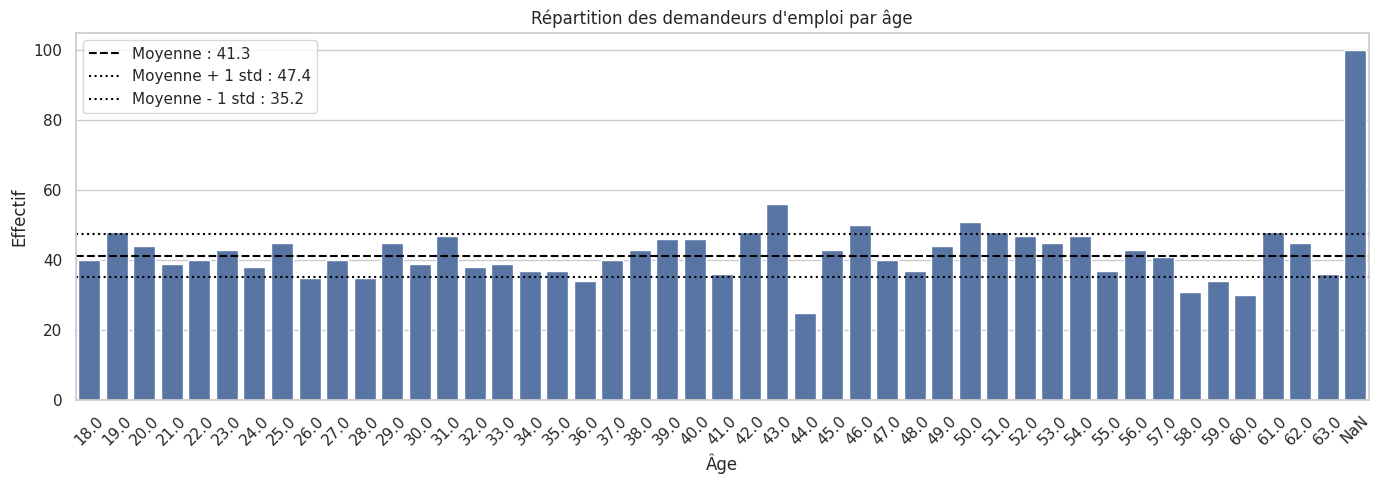

In [8]:
# Transformer les âges en libellés et les NaN en catégorie
age_affichage = df_train["age"].apply(
    lambda valeur: "NaN" if pd.isna(valeur) else str(valeur)
)

# Ordre d'affichage : âges croissants puis NaN
ordre = [
    str(age)
    for age in sorted(df_train["age"].dropna().unique())
] + ["NaN"]

# Effectif de chaque âge, NaN compris
effectifs = (
    age_affichage
    .value_counts()
    .reindex(ordre, fill_value=0)
)

# Moyenne des effectifs par modalité
effectif_moyen = effectifs.drop("NaN").mean()
ecart_type = effectifs.drop("NaN").std()

plt.figure(figsize=(14, 5))

ax = sns.countplot(
    x=age_affichage,
    order=ordre
)

ax.axhline(
    effectif_moyen,
    color="black",
    linestyle="--",
    label=f"Moyenne : {effectif_moyen:.1f}"
)

ax.axhline(
    effectif_moyen + ecart_type,
    color="black",
    linestyle=":",
    label=f"Moyenne + 1 std : {effectif_moyen + ecart_type:.1f}"
)

ax.axhline(
    max(0, effectif_moyen - ecart_type),
    color="black",
    linestyle=":",
    label=f"Moyenne - 1 std : {max(0, effectif_moyen - ecart_type):.1f}"
)

print("Effectif minimum :", effectifs.drop("NaN").min())
print("Âge concerné :", effectifs.drop("NaN").idxmin())
print("Effectif maximum :", effectifs.drop("NaN").max())
print("Âge concerné :", effectifs.drop("NaN").idxmax())
print("Effectif maximum :", effectifs.max())
print("Âge concerné :", effectifs.idxmax())

plt.title("Répartition des demandeurs d'emploi par âge")
plt.xlabel("Âge")
plt.ylabel("Effectif")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

A la première lecture on ne constate :
- Il n'y a pas de valeurs abbérantes sur l'axe des abscisses.
- La moyenne des effectifs (hors NaN) se situe à 51.7 avec ecart type de 44.5 - 58.9.
 - 3 catégories au dessus 47.4 (Max => 56 demandeurs agé 43 ans)
 - 4 catégories en dessous de 35.2 (Min => 25 demandeurs agé 44 ans)
 - La catégorie 'NaN' represente a elle seule **100 demandeurs**.

Hormis la catégorie 'Nan', les données 'age' sont plutôt équilibrées, la problématique va venir sur la stratégie d'imputation de la catégorie 'Nan' (effectif = 100) qui represente à elle seule 100/41.3 = **2.42 fois** la moyenne. Choisir une imputation de la mediane des ages n'est pas la bonne option car elle va desequilibrer la répartition vers la médiane globale.

#### 3.3.1 Approche sur l'imputation des données pour l'`age` à partir `anciennete_poste_ans` et `niveau_diplome`

Pour imputer les données d'`age` du demandeur, nous pouvons nous appuyer sur les deux features :  `anciennete_poste_ans` et `niveau_diplome` (cf. 2.2 réflexion faite sur le dictionaire). En effet, par similarité des profils (`niveau_diplome` et `anciennete_postes_ans`) nous pouvons réaliser la médiane par groupe et l'imputer pour les ages manquants. Je propose que nous équilibrions les catégories anciennete_postes_ans en 3, 4 et 5 categories :

In [9]:
# Copie des données pour travailler sur la categorie anciennete_poste_ans
df_anciennete_poste_ans = df_train.copy()

resultats_decoupage = []

# Boucle sur les 3 propositions (3, 4 ou 5 categories)
for i in range(3, 6):

    # Calcule des tranches en % => 33%, 25% ou 20%
    tranches = pd.qcut(
        df_anciennete_poste_ans["anciennete_poste_ans"],
        q=i
    )

    effectifs = tranches.dropna().value_counts(sort=False)

    # Calcule de la moyenne et des écarts types
    moyenne = effectifs.mean()
    ecart_type = effectifs.std()
    coefficient_variation = ecart_type / moyenne * 100

    print(f"\n--- Découpage en {i} catégories ---")
    display(effectifs)

    resultats_decoupage.append({
        "Nombre de catégories": i,
        "Effectif minimum": effectifs.min(),
        "Effectif maximum": effectifs.max(),
        "Effectif moyen": round(moyenne, 2),
        "Écart-type": round(ecart_type, 2),
        "Coefficient de variation (%)": round(
            coefficient_variation,
            2
        )
    })

display(pd.DataFrame(resultats_decoupage))


--- Découpage en 3 catégories ---


anciennete_poste_ans
(-0.001, 1.2]    685
(1.2, 3.2]       650
(3.2, 22.6]      665
Name: count, dtype: int64


--- Découpage en 4 catégories ---


anciennete_poste_ans
(-0.001, 0.8]    503
(0.8, 2.1]       529
(2.1, 4.1]       471
(4.1, 22.6]      497
Name: count, dtype: int64


--- Découpage en 5 catégories ---


anciennete_poste_ans
(-0.001, 0.6]    405
(0.6, 1.5]       414
(1.5, 2.7]       400
(2.7, 4.8]       388
(4.8, 22.6]      393
Name: count, dtype: int64

,Nombre de catégories,Effectif minimum,Effectif maximum,Effectif moyen,Écart-type,Coefficient de variation (%)
0,3,650,685,666.67,17.56,2.63
1,4,471,529,500.00,23.80,4.76
2,5,388,414,400.00,10.17,2.54


Finalement de découpage en **5 catégories** est celle qui présente le moins d'écart-type et de variation :
- "0-0.6 an",
- "0.6-1.5 ans",
- "1.5-2.7 ans",
- "2.7-4.8 ans",
- "4.8 ans et plus"

regardons la répartition en fonction sur une graphique et comparons là avec le précédent graphique :

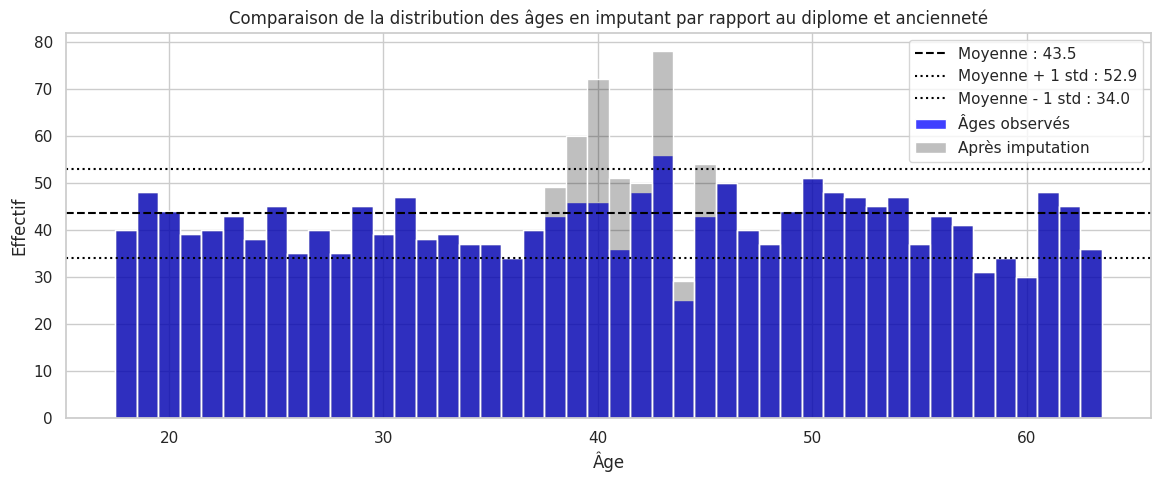

,age,age_impute,niveau_diplome,tranche_anciennete


NaN après Imputation : 0


In [10]:
# Copie de travail
df_age = df_train.copy()

# Classification en 4 catégories de la feature tranche_anciennete cf. §3.3.1
df_age["tranche_anciennete"] = pd.cut(
    df_age["anciennete_poste_ans"],
    bins=[-1, 0.6, 1.5, 2.7, 4.8, float("inf")], # Je laisse volontairement infini car l'age de la retraite reculent tous les ans.
    labels=[
     "0-0.6 an",
     "0.6-1.5 ans",
     "1.5-2.7 ans",
     "2.7-4.8 ans",
     "4.8 ans et plus"
    ]
)

# Recopie des données
df_age["age_impute"] = df_age["age"]

# Calcul de la médian par rapport au groupement niveau de diplome et tranche_anciennete
mediane_groupe_1 = df_age.groupby(
    [
       "niveau_diplome",
        "tranche_anciennete"
    ],
    dropna=False,
    observed=True 
)["age"].transform(
    lambda serie: serie.quantile(
        0.5,
        interpolation="nearest"
    )
)

# Imputation des ages 'NaN'
df_age["age_impute"] = df_age["age_impute"].fillna(
    mediane_groupe_1
)

plt.figure(figsize=(14, 5))

ax = sns.histplot(
    df_age["age"].dropna(),
    color='Blue',
    discrete=True,
    label="Âges observés",
    alpha=0.75
)

sns.histplot(
    df_age["age_impute"],
    color='Black',
    discrete=True,
    label="Après imputation",
    alpha=0.25
)

# Moyenne des effectifs par modalité
effectifs = (
    df_age["age_impute"]
    .dropna()
    .value_counts()
)

effectif_moyen = effectifs.mean()
ecart_type = effectifs.std()

ax.axhline(
    effectif_moyen,
    color="black",
    linestyle="--",
    label=f"Moyenne : {effectif_moyen:.1f}"
)

ax.axhline(
    effectif_moyen + ecart_type,
    color="black",
    linestyle=":",
    label=f"Moyenne + 1 std : {effectif_moyen + ecart_type:.1f}"
)

ax.axhline(
    max(0, effectif_moyen - ecart_type),
    color="black",
    linestyle=":",
    label=f"Moyenne - 1 std : {max(0, effectif_moyen - ecart_type):.1f}"
)


plt.title("Comparaison de la distribution des âges en imputant par rapport au diplome et ancienneté")
plt.xlabel("Âge")
plt.ylabel("Effectif")
plt.legend()
plt.show()

# Etape de verification
masque_age_manquant = df_age["age_impute"].isna()

display(
    df_age.loc[
        masque_age_manquant,
        [
            "age",
            "age_impute",
            "niveau_diplome",
            "tranche_anciennete"
        ]
    ]
)
print("NaN après Imputation :", df_age["age_impute"].isna().sum())

Nous observons :
- La moyenne a augmentée de **41.3 -> 43.5**.
- La répartition des imputations est centrée autour de 41 ans (38 -> 45 ans).
- Il n'y a pas plus de NaN après cette imputation.

Ces pics autour de 38 à 45 ans montrent que l’imputation par médiane de groupe concentre beaucoup de valeurs sur quelques âges. C’est un signal d’alerte : la méthode semble partiellement écraser la variabilité de l’âge.

Verifions avec un masquage artificiel des données connues et calculons la MAE :

In [11]:
colonnes_groupe = [
    "niveau_diplome",
    "tranche_anciennete"
]

df_age_connu = df_age.loc[
    df_age["age"].notna()
].copy()

# Fonction détaillée dans le fichier eda.py
resultats_validation = validation_mae(df_age_connu, colonnes_groupe, "age")

display(resultats_validation)

#Evaluation de la MAE Moyenne
display (resultats_validation["MAE"].mean())

,seed,MAE,Erreur_mediane,RMSE,age_exact_%,Erreur_de_2_unites_%,Erreur_de_5_unites_%,Erreur_de_10_unites_%
0,0,11.271053,11.0,13.036689,3.157895,12.368421,22.631579,45.789474
1,1,11.123684,10.0,13.088464,1.052632,11.315789,27.105263,51.842105
2,2,11.657895,11.0,13.662665,2.894737,12.368421,23.157895,48.421053
3,3,12.165789,12.0,14.028449,1.578947,8.421053,21.578947,45.000000
4,4,11.692105,11.0,13.535626,1.052632,10.000000,22.894737,45.000000
5,5,12.005263,11.0,13.961224,2.105263,9.736842,21.315789,47.105263
6,6,11.613158,11.0,13.523177,1.315789,9.736842,23.947368,47.368421
7,7,11.236842,11.0,13.290875,1.842105,10.526316,27.894737,49.473684
8,8,11.739474,11.0,13.694121,1.842105,11.842105,24.736842,45.263158
9,9,11.710526,12.0,13.417977,1.315789,9.473684,21.578947,45.000000


np.float64(11.621578947368421)

Les résultats sont sans appel : la méthode d’imputation obtient une MAE moyenne d’environ **11,5 ans**, ce qui représente une erreur importante au regard de l’étendue de la variable age, comprise entre 18 et 63 ans. Le pourcentage d’âges exactement retrouvés reste faible, autour de **2 à 3 %**. Les variables `anciennete_poste_ans` et `niveau_diplome` ne contiennent donc pas suffisamment d’information pour estimer précisément l’âge.

Il est nécessaire d’évaluer l’apport d’une variable supplémentaire présentant une relation plausible avec l’âge. La variable `code_rome_vise` constitue une candidate potentielle, car le métier recherché peut être associé à des parcours professionnels et à des profils d’âge différents. Toutefois, sa cardinalité élevée, avec 50 modalités, peut produire des groupes de faible effectif et des médianes peu robustes. Il serait donc pertinent de tester d’abord une variable plus générale, telle que `famille_rome`, puis de comparer objectivement les différentes méthodes par masquage artificiel à l’aide de la MAE et de la RMSE.

#### 3.3.2 Approche sur l'imputation des données pour l'`age` à partir `anciennete_poste_ans`, `niveau_diplome` et `code_rome_vise`

La variable `code_rome_vise` est une chaine de caractère normée à savoir 1 lettre et 4 chiffres. La lettre correspond à la famille de métier et les 4 chiffres qui identifient spécifiquement un métier. Nous pouvons nous appuyer sur la lettre uniquement pour créer la feature `famille_rome` et regardons la distribution.

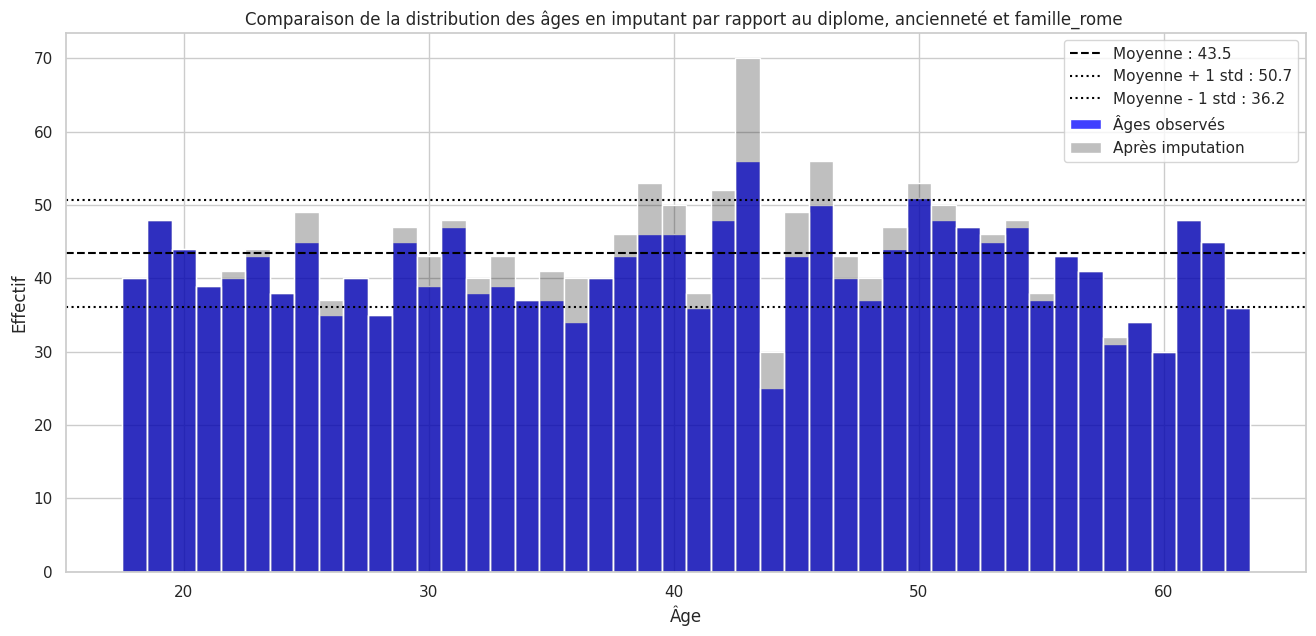

,age,age_impute2,niveau_diplome,famille_rome,tranche_anciennete


NaN après Imputation : 0


In [12]:
# Création de la feature 'famille_rome'
df_age["famille_rome"] = (
    df_age["code_rome_vise"]
    .astype("string")
    .str[0]
)

# Recopie des données
df_age["age_impute2"] = df_age["age"]

# Calcul de la médian par rapport au groupement niveau de diplome, tranche_anciennete et famille_rome
mediane_groupe_2 = df_age.groupby(
    [
       "niveau_diplome",
        "tranche_anciennete",
        "famille_rome"
    ],
    dropna=False,
    observed=True 
)["age"].transform(
    lambda serie: serie.quantile(
        0.5,
        interpolation="nearest"
    )
)

# Imputation des ages 'NaN'
df_age["age_impute2"] = df_age["age_impute2"].fillna(
    mediane_groupe_2
)

plt.figure(figsize=(16, 7))

ax = sns.histplot(
    df_age["age"].dropna(),
    color='Blue',
    discrete=True,
    label="Âges observés",
    alpha=0.75
)

sns.histplot(
    df_age["age_impute2"],
    color='Black',
    discrete=True,
    label="Après imputation",
    alpha=0.25
)

# Moyenne des effectifs par modalité
effectifs = (
    df_age["age_impute2"]
    .dropna()
    .value_counts()
)

effectif_moyen = effectifs.mean()
ecart_type = effectifs.std()

ax.axhline(
    effectif_moyen,
    color="black",
    linestyle="--",
    label=f"Moyenne : {effectif_moyen:.1f}"
)

ax.axhline(
    effectif_moyen + ecart_type,
    color="black",
    linestyle=":",
    label=f"Moyenne + 1 std : {effectif_moyen + ecart_type:.1f}"
)

ax.axhline(
    max(0, effectif_moyen - ecart_type),
    color="black",
    linestyle=":",
    label=f"Moyenne - 1 std : {max(0, effectif_moyen - ecart_type):.1f}"
)


plt.title("Comparaison de la distribution des âges en imputant par rapport au diplome, ancienneté et famille_rome ")
plt.xlabel("Âge")
plt.ylabel("Effectif")
plt.legend()
plt.show()

# Etape de verification
masque_age_manquant = df_age["age_impute"].isna()

display(
    df_age.loc[
        masque_age_manquant,
        [
            "age",
            "age_impute2",
            "niveau_diplome",
            "famille_rome",
            "tranche_anciennete"
        ]
    ]
)
print("NaN après Imputation :", df_age["age_impute"].isna().sum())

Nous observons :
- La moyenne a augmentée de **41.3 -> 54.3** (Pour rappel : 43.5 avec uniquement diplome et ancienneté).
- La répartition reste toujours trés présente autour de 41 ans cependant elle est visuellement plus étalée sur les autres âges.
- Il n'y a pas plus de NaN après cette imputation.

Verifions avec un masquage artificiel des données connues et calculons la MAE :

In [13]:
colonnes_groupe = [
    "niveau_diplome",
    "tranche_anciennete",
    "famille_rome",
    "nationalite_hors_ue"
]

# 1	age	float64	46	18.0	63.0
# 2	niveau_diplome	object	4	Non applicable	Non applicable
# 4	code_rome_vise	object	50	A1202	W1401
# 5	code_insee_commune	object	2407	01007	97601
# 6	est_allocataire	float64	2	0.0	1.0
# 7	nationalite_hors_ue	int64	2	0	1
# 8	synthese_entretien	object	9	Non applicable	Non applicable
# 9	classe_retour_emploi


df_age_connu = df_age.loc[
    df_age["age"].notna()
].copy()

# Fonction détaillée dans le fichier eda.py
resultats_validation = validation_mae(df_age_connu, colonnes_groupe, "age")

display(resultats_validation)

#Evaluation de la MAE Moyenne
display (resultats_validation["MAE"].mean())

,seed,MAE,Erreur_mediane,RMSE,age_exact_%,Erreur_de_2_unites_%,Erreur_de_5_unites_%,Erreur_de_10_unites_%
0,0,12.589474,12.0,15.094265,2.368421,11.578947,25.000000,45.526316
1,1,12.902632,12.0,15.438247,1.842105,10.789474,23.947368,42.894737
2,2,12.689474,11.0,15.259854,1.578947,10.789474,23.947368,46.842105
3,3,13.036842,12.0,15.564129,1.052632,9.210526,22.631579,42.631579
4,4,12.931579,12.0,15.624037,2.105263,11.578947,24.473684,45.526316
5,5,12.431579,11.0,15.061278,2.105263,10.789474,25.789474,47.631579
6,6,13.042105,12.0,15.847464,2.105263,8.684211,25.526316,45.526316
7,7,11.668421,10.0,14.198221,2.368421,11.052632,29.736842,51.052632
8,8,12.636842,11.0,15.031896,2.368421,9.210526,23.157895,46.315789
9,9,12.710526,11.5,15.257267,1.315789,10.000000,24.473684,46.578947


np.float64(12.663947368421052)

On observe que l'ajout de la feature `famille_rome` dégrade les résultats MAE passe de 11.53 (uniquement`anciennete_poste_ans`, `niveau_diplome`) à **12.32**. Cette segmentation supplémentaire ne permet donc pas de mieux estimer l’âge. Elle produit probablement des groupes plus petits et moins représentatifs, dont les médianes sont moins robustes.

Comme les imputations conditionnelles n’améliorent pas les résultats, je teste maintenant une solution plus simple : la médiane globale. 

#### 3.3.3 Approche sur l'imputation des données pour l'age à partir de la médiane globale

Calculons directement la MAE d'une approche globale

In [14]:
resultats_mediane_globale = validation_mediane_globale(
    df_age,
    feature_name="age"
)

display(resultats_mediane_globale)
#Evaluation de la MAE Moyenne
display (resultats_mediane_globale["MAE"].mean())

,seed,Mediane_globale,MAE,Erreur_mediane,RMSE,age_exact_%,Erreur_de_2_unites_%,Erreur_de_5_unites_%,Erreur_de_10_unites_%
0,0,40.0,11.123684,11.0,12.850456,3.421053,12.368421,22.894737,46.842105
1,1,41.0,10.802632,11.0,12.619221,1.315789,12.631579,27.368421,49.736842
2,2,41.0,11.344737,11.0,13.284637,1.842105,13.684211,26.842105,47.631579
3,3,41.0,11.700000,12.0,13.486445,2.105263,10.789474,23.157895,44.473684
4,4,41.0,11.557895,12.0,13.364328,2.631579,11.842105,23.157895,45.789474
5,5,41.0,11.702632,11.5,13.426114,1.578947,9.473684,22.894737,45.000000
6,6,41.0,11.655263,11.0,13.460371,1.578947,9.736842,22.894737,47.368421
7,7,41.0,10.886842,10.0,12.806968,3.421053,14.736842,26.315789,52.368421
8,8,41.0,11.497368,11.0,13.352410,2.368421,12.894737,23.947368,46.052632
9,9,41.0,11.563158,12.0,13.325085,1.842105,12.105263,22.894737,44.210526


np.float64(11.38342105263158)

L’évaluation répétée de l’imputation par médiane globale produit une MAE moyenne de **11,38** ans. Cette méthode obtient de meilleurs résultats que les imputations conditionnelles précédemment testées, dont la MAE atteignait 11,53 ans avec niveau_diplome et anciennete_poste_ans, puis 12,32 ans après l’ajout de famille_rome.


#### 3.3.4 Contrôle des incohérences métier liées à l`age`


##### 3.3.4.1 Incohérence avec `anciennete_poste_ans`

Au-delà des valeurs manquantes et de la distribution de `age`, un contrôle de cohérence métier est réalisé avec la variable `anciennete_poste_ans`.

L'ancienneté déclarée ne doit pas conduire à un âge de début d'activité manifestement incohérent.  
On calcule donc un âge théorique de début du poste :

[age_debut_poste = age - anciennete_poste_ans]

Les observations conduisant à un âge de début de poste inférieur à **16 ans** sont considérées comme des incohérences métier potentielles et sont examinées séparément. (**Je prends comme hypothèse que l'age minimum est 16 ans**)

Ce contrôle permet notamment d'éviter que des observations incohérentes perturbent l'analyse des relations entre l'âge et l'ancienneté.

In [15]:
df_age_coherence = df_train[
    df_train["age"].notna()
    & df_train["anciennete_poste_ans"].notna()
].copy()

df_age_coherence["age_debut_poste"] = (
    df_age_coherence["age"]
    - df_age_coherence["anciennete_poste_ans"]
)

df_age_incoherent = df_age_coherence[
    df_age_coherence["age_debut_poste"] < 16
]

display(
    df_age_incoherent[
        [
            "usager_id",
            "age",
            "anciennete_poste_ans",
            "age_debut_poste",
        ]
    ].sort_values("age_debut_poste")
)
print(
    f"Nombre d'incohérences âge / ancienneté : "
    f"{len(df_age_incoherent)} / {len(df_age_coherence)}"
)

print(
    f"Soit {len(df_age_incoherent) / len(df_age_coherence) * 100:.2f} % "
    "des observations exploitables."
)

,usager_id,age,anciennete_poste_ans,age_debut_poste
1075,ID_1075,22.0,20.2,1.8
495,ID_0495,18.0,15.5,2.5
1979,ID_1979,18.0,12.8,5.2
1495,ID_1495,20.0,14.3,5.7
429,ID_0429,18.0,9.8,8.2
...,...,...,...,...
1313,ID_1313,34.0,18.2,15.8
2044,ID_2044,25.0,9.1,15.9
2388,ID_2388,23.0,7.1,15.9
22,ID_0022,19.0,3.1,15.9


Nombre d'incohérences âge / ancienneté : 81 / 1900
Soit 4.26 % des observations exploitables.


##### 3.3.4.2 Incohérence avec `niveau_diplome`

L'âge peut également être comparé au niveau de diplôme déclaré afin d'identifier certaines incohérences métier.

Par exemple, un niveau `Bac+5` associé à un âge de 16 ans n'est pas cohérent avec la durée minimale nécessaire pour atteindre ce niveau d'études.

Pour éviter de considérer comme anomalie un parcours simplement atypique ou accéléré, je retiens volontairement des seuils d'âge minimum assez conservateurs :

- `Bac` : 16 ans minimum ;
- `Bac+2` : 18 ans minimum ;
- `Bac+5` : 20 ans minimum.

Ces seuils ne représentent pas l'âge habituel d'obtention du diplôme. Ils servent uniquement à détecter les combinaisons manifestement incohérentes.

In [16]:
df_age_diplome = df_train[
    df_train["age"].notna()
    & df_train["niveau_diplome"].notna()
].copy()

df_age_diplome["age_min_diplome"] = (
    df_age_diplome["niveau_diplome"]
    .map(AGE_MIN_PAR_DIPLOME)
)

df_age_diplome_incoherent = df_age_diplome[
    df_age_diplome["age_min_diplome"].notna()
    & (
        df_age_diplome["age"]
        < df_age_diplome["age_min_diplome"]
    )
]

display(
    df_age_diplome_incoherent[
        [
            "usager_id",
            "age",
            "niveau_diplome",
            "age_min_diplome",
        ]
    ].sort_values("age")
)

print(
    f"Nombre d'incohérences âge / diplôme : "
    f"{len(df_age_diplome_incoherent)}"
)

print(
    f"Soit "
    f"{len(df_age_diplome_incoherent) / len(df_age_diplome) * 100:.2f} % "
    "des observations exploitables."
)

,usager_id,age,niveau_diplome,age_min_diplome
495,ID_0495,18.0,Bac+5,20.0
608,ID_0608,18.0,Bac+5,20.0
2036,ID_2036,18.0,Bac+5,20.0
1955,ID_1955,18.0,Bac+5,20.0
380,ID_0380,18.0,Bac+5,20.0
207,ID_0207,18.0,Bac+5,20.0
1257,ID_1257,18.0,Bac+5,20.0
1813,ID_1813,19.0,Bac+5,20.0
972,ID_0972,19.0,Bac+5,20.0
1824,ID_1824,19.0,Bac+5,20.0


Nombre d'incohérences âge / diplôme : 13
Soit 0.71 % des observations exploitables.


Certaines observations présentent une combinaison incohérente entre l'âge et le niveau de diplôme déclaré.

#### 3.3.5 Conclusion imputation `age`

Les différentes méthodes testées ne permettent pas d'estimer suffisamment précisément l'âge manquant à partir des autres variables disponibles.

Parmi les stratégies évaluées, la médiane globale donne néanmoins les meilleurs résultats. Elle est également plus simple et plus stable que les méthodes d'imputation par regroupement. Je retiens donc cette méthode pour remplacer les valeurs manquantes de la feature `age`.

Cette imputation introduit toutefois une ambiguïté : après traitement, il n'est plus possible de distinguer un âge réellement égal à la médiane d'un âge qui a été imputé. J'ajoute donc une nouvelle feature binaire `age_manquant` :

- `0` : l'âge était renseigné dans les données initiales ;
- `1` : l'âge était manquant et a été remplacé par la médiane.

Les contrôles de cohérence métier ont également mis en évidence certaines observations pour lesquelles l'âge renseigné est incompatible avec `anciennete_poste_ans` ou `niveau_diplome`.

Comme il n'est pas possible de déterminer quelle valeur est erronée, je ne corrige pas automatiquement ces observations. Elles sont exclues des analyses et traitements utilisant la feature `age`, afin de ne pas introduire des données incohérentes dans le modèle.

Pour la suite des traitements impliquant la feature `age`, seules les observations ne présentant pas d’incohérence métier sont utilisées. Les autres analyses restent réalisées sur le jeu de données initial.

**Décision retenue :**

| feature | **`Scénario 1`** | **`Scénario 2`** | **`Scénario 3`** | **`Scénario 4`** |
|:---:|:---:|:---:|:---:|:---:|
| `age` | ✅ conservée</br>médiane + feature `age_manquant`</br>exclusion des incohérences métier | ❌ écartée | ❌ écartée | ✅ conservée</br>médiane + feature `age_manquant`</br>exclusion des incohérences métier |

In [17]:
masque_age_incoherent = masque_incoherences_age(X_train)

print(
    "Nombre total d'observations incohérentes liées à l'âge :",
    masque_age_incoherent.sum()
)

display(
    X_train.loc[
        masque_age_incoherent,
        [
            "usager_id",
            "age",
            "niveau_diplome",
            "anciennete_poste_ans",
        ]
    ]
)

# On exclue les incohrénces métiers 
X_train_age = X_train.loc[~masque_age_incoherent].copy()
y_train_age = y_train.loc[~masque_age_incoherent].copy()

Nombre total d'observations incohérentes liées à l'âge : 89


,usager_id,age,niveau_diplome,anciennete_poste_ans
2284,ID_2284,22.0,Sans diplôme,7.8
2078,ID_2078,21.0,Bac,9.0
1061,ID_1061,19.0,Bac+2,6.7
1035,ID_1035,19.0,Bac+2,6.7
2388,ID_2388,23.0,Bac+2,7.1
...,...,...,...,...
700,ID_0700,19.0,Sans diplôme,4.9
506,ID_0506,19.0,Bac+5,5.9
302,ID_0302,20.0,Bac,8.1
222,ID_0222,23.0,Sans diplôme,7.1


###  3.4 Analyse des données - feature `niveau_diplome`

La variable `niveau_diplome` correspond au plus haut niveau de diplôme obtenu par le demandeur d’emploi. Une première observation réalisée lors de l’analyse générale des données, présentée en section 3.1, met en évidence la présence de valeurs manquantes. Une stratégie de traitement doit donc être définie avant l’entraînement des modèles.

La variable contient quatre modalités observées :

- Sans diplôme
- Bac
- Bac+2
- Bac+5

Effectif minimum hors NaN : 366
Diplôme concerné : Bac+5
Effectif maximum hors NaN : 779
Diplôme concerné : Bac
Nombre de valeurs NaN : 68


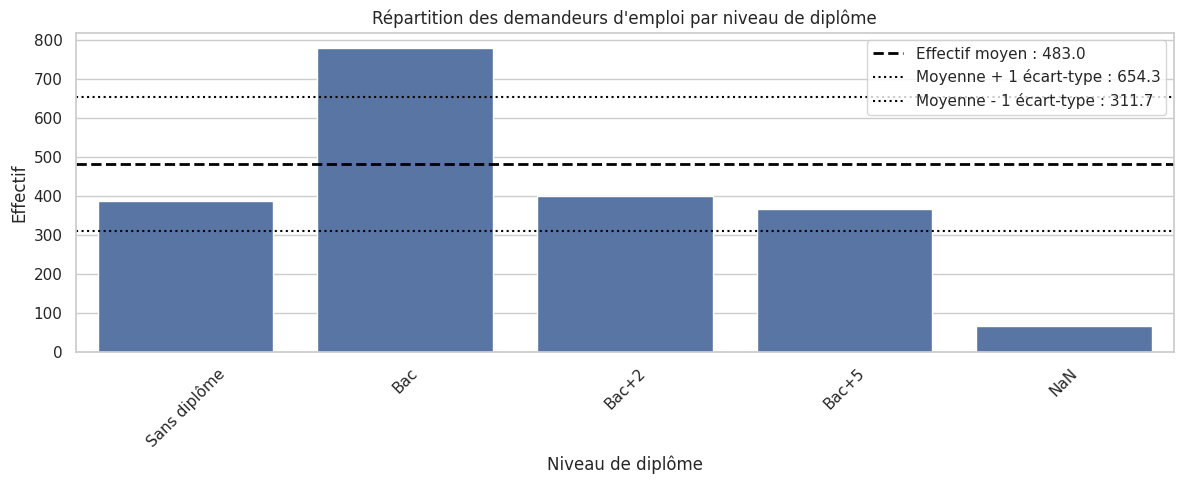

In [18]:
# Transformer les valeurs manquantes en catégorie explicite
diplome_affichage = (
    df_train["niveau_diplome"]
    .fillna("NaN")
    .astype(str)
)

# Ordre d'affichage des catégories
ordre = [
    "Sans diplôme",
    "Bac",
    "Bac+2",
    "Bac+5",
    "NaN"
]

# Conserver uniquement les modalités réellement présentes
ordre = [
    diplome
    for diplome in ordre
    if diplome in diplome_affichage.unique()
]

# Effectif de chaque niveau de diplôme, NaN compris
effectifs = (
    diplome_affichage
    .value_counts()
    .reindex(ordre, fill_value=0)
)

# Exclure NaN du calcul des statistiques
effectifs_sans_nan = effectifs.drop(
    index="NaN",
    errors="ignore"
)

# Moyenne et écart-type des effectifs par modalité
effectif_moyen = effectifs_sans_nan.mean()
ecart_type = effectifs_sans_nan.std(ddof=0)

plt.figure(figsize=(12, 5))

ax = sns.countplot(
    x=diplome_affichage,
    order=ordre
)

# Effectif moyen
ax.axhline(
    y=effectif_moyen,
    color="black",
    linestyle="--",
    linewidth=2,
    label=f"Effectif moyen : {effectif_moyen:.1f}"
)

# Effectif moyen + un écart-type
ax.axhline(
    y=effectif_moyen + ecart_type,
    color="black",
    linestyle=":",
    label=(
        "Moyenne + 1 écart-type : "
        f"{effectif_moyen + ecart_type:.1f}"
    )
)

# Effectif moyen - un écart-type
ax.axhline(
    y=max(0, effectif_moyen - ecart_type),
    color="black",
    linestyle=":",
    label=(
        "Moyenne - 1 écart-type : "
        f"{max(0, effectif_moyen - ecart_type):.1f}"
    )
)

print(
    "Effectif minimum hors NaN :",
    effectifs_sans_nan.min()
)
print(
    "Diplôme concerné :",
    effectifs_sans_nan.idxmin()
)

print(
    "Effectif maximum hors NaN :",
    effectifs_sans_nan.max()
)
print(
    "Diplôme concerné :",
    effectifs_sans_nan.idxmax()
)

print(
    "Nombre de valeurs NaN :",
    effectifs.get("NaN", 0)
)

plt.title(
    "Répartition des demandeurs d'emploi "
    "par niveau de diplôme"
)
plt.xlabel("Niveau de diplôme")
plt.ylabel("Effectif")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

L’analyse de la distribution sur le jeu d’entraînement montre que la catégorie `Bac` est la plus représentée, avec **779 observations**, tandis que la catégorie `Bac+5` est la moins représentée, avec **366 observations**. La distribution est donc modérément déséquilibrée en faveur de la modalité `Bac`.

Par ailleurs, **68 valeurs sont manquantes** dans le jeu d’entraînement. Ces valeurs ne peuvent pas être attribuées de manière fiable à l’une des quatre catégories existantes. Une imputation par la modalité majoritaire, par exemple Bac, augmenterait artificiellement la représentation de cette catégorie et reviendrait à attribuer un diplôme sans justification factuelle.

Les valeurs manquantes seront donc remplacées par une modalité spécifique : `Non renseigné`

Cette stratégie conserve explicitement l’information relative à l’absence de réponse, sans introduire d’hypothèse non vérifiable sur le niveau réel de diplôme du demandeur d’emploi.

Contrairement à la feature `age`, il n’est pas nécessaire de créer une variable binaire supplémentaire telle que `niveau_diplome_manquant`. La modalité `Non renseigné` joue déjà ce rôle et permet au modèle d’identifier directement les observations pour lesquelles le diplôme était absent. La stratégie retenue consiste à conserver la feature `niveau_diplome` et à remplacer les valeurs manquantes par la modalité `Non renseigné`. Cette approche évite d’attribuer arbitrairement un diplôme aux demandeurs d’emploi et préserve l’information portée par l’absence de réponse.

Actions préconisées :

| feature | **`Scénario 1`** | **`Scénario 2`** | **`Scénario 3`** | **`Scénario 4`** |
|:---:|:---:|:---:|:---:|:---:|
|`niveau_diplome`|✅ retenue</br>imputation avec Modalité `Non renseigné`|✅ retenue</br>imputation avec Modalité `Non renseigné`|❌ écartée|✅ retenue</br>imputation avec Modalité `Non renseigné` |

###  3.5 Analyse des données - feature `anciennete_poste_ans`

La variable `anciennete_poste_ans` ne contient aucune valeur manquante. Aucun traitement d’imputation n’est donc nécessaire. L’analyse portera uniquement sur sa distribution et sur la vérification des valeurs atypiques détectées par la méthode de l’IQR.

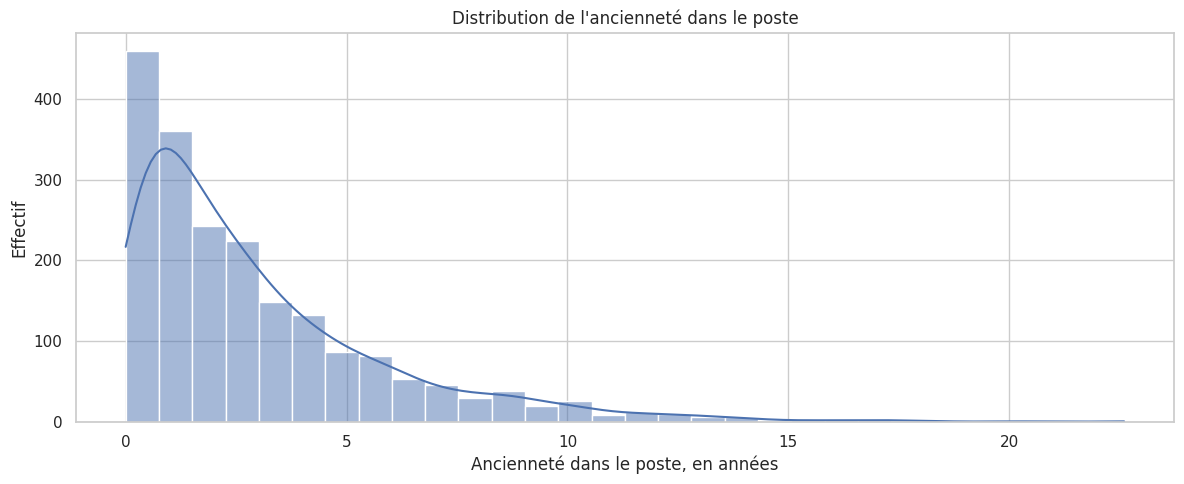

In [19]:
# Ce code utilise un histogramme plutôt qu’un countplot, car anciennete_poste_ans est une variable quantitative continue
# comportant 154 valeurs distinctes. Afficher une barre pour chaque valeur exacte rendrait le graphique très chargé et difficile à interpréter.
plt.figure(figsize=(12, 5))

# Représentation de la distribution de l'ancienneté
sns.histplot(
    data=df_train,

    # Variable quantitative étudiée
    x="anciennete_poste_ans",

    # Regroupement des valeurs dans 30 intervalles.
    # Cela permet d'obtenir une représentation plus lisible
    # que l'affichage d'une barre pour chacune des 154 valeurs.
    bins=30,

    # Ajout d'une estimation lissée de la densité.
    # Cette courbe aide à visualiser la forme générale
    # de la distribution et son asymétrie.
    kde=True
)

# Titre du graphique
plt.title(
    "Distribution de l'ancienneté dans le poste"
)

# Libellé de l'axe horizontal
plt.xlabel(
    "Ancienneté dans le poste, en années"
)

# Libellé de l'axe vertical
plt.ylabel("Effectif")

# Ajustement automatique des marges
# afin d'éviter que les titres soient coupés
plt.tight_layout()

# Affichage du graphique
plt.show()

La variable `anciennete_poste_ans` ne contient aucune valeur manquante et ne nécessite donc aucune imputation. Sa distribution est fortement asymétrique à droite : les faibles anciennetés sont majoritaires et les effectifs diminuent progressivement lorsque l’ancienneté augmente. La valeur la plus fréquente est de **0,2 an**, observée pour **75 demandeurs d’emploi**, tandis que l’ancienneté maximale atteint **22,6 ans**.

La méthode de l’IQR identifie **99 observations** supérieures à environ **3.3 ans** comme atypiques. Ces valeurs restent toutefois réalistes au regard du contexte métier. Elles sont donc considérées comme des valeurs extrêmes plausibles et sont conservées dans le dataset. Aucun traitement correctif n’est appliqué à cette feature.

Actions préconisées :

| feature | **`Scénario 1`** | **`Scénario 2`** | **`Scénario 3`** | **`Scénario 4`** |
|:---:|:---:|:---:|:---:|:---:|
|`anciennete_poste_ans`|✅ retenue|✅ retenue|❌ écartée|✅ retenue|

###  3.6 Analyse des données - feature `code_rome_vise`

La variable `code_rome_vise` correspond au code du métier visé par le demandeur d’emploi. Malgré la présence de chiffres, il s’agit d’une variable catégorielle nominale et non d’une variable numérique. A noter qu'il y a **aucune valeur manquante** et que le dataset fait état de **50 codes différents**.

Nombre de valeurs manquantes : 0
Nombre de codes ROME différents : 50
Effectif moyen par code : 40.0
Effectif minimum : 21
Code concerné : W1401
Effectif maximum : 56
Code concerné : H1206


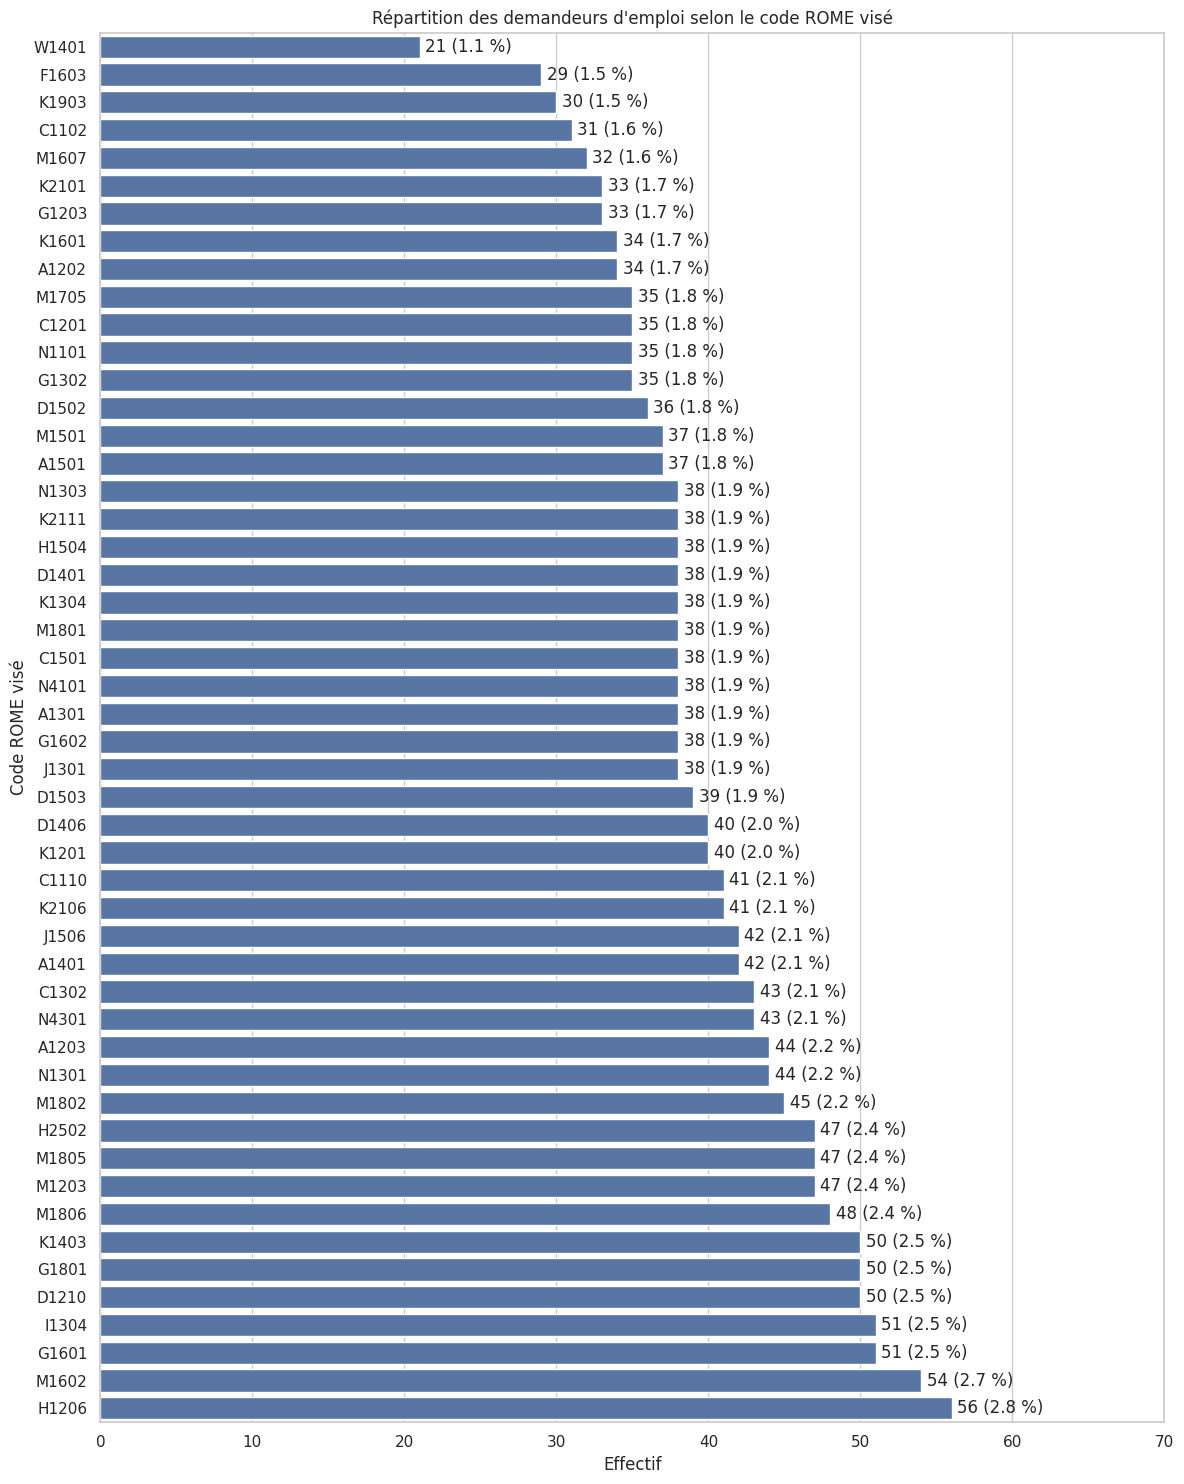

In [20]:
# Préparation de la série sans modifier le DataFrame initial
code_rome_affichage = (
    df_train["code_rome_vise"]
    .astype("string")
    .str.strip()
    .str.upper()
)

# Effectif par code ROME
effectifs = (
    code_rome_affichage
    .value_counts()
    .sort_values()
)

print(
    "Nombre de valeurs manquantes :",
    code_rome_affichage.isna().sum()
)

print(
    "Nombre de codes ROME différents :",
    code_rome_affichage.nunique()
)

print(
    "Effectif moyen par code :",
    round(effectifs.mean(), 2)
)

print(
    "Effectif minimum :",
    effectifs.min()
)

print(
    "Code concerné :",
    effectifs.idxmin()
)

print(
    "Effectif maximum :",
    effectifs.max()
)

print(
    "Code concerné :",
    effectifs.idxmax()
)

# Effectifs classés du moins fréquent au plus fréquent
ordre = effectifs.index

plt.figure(figsize=(12, 15))

ax = sns.countplot(
    data=df_train,
    y="code_rome_vise",
    order=ordre
)

total = len(df_train)

# Affichage de l'effectif et du pourcentage
for barre in ax.patches:
    effectif = int(barre.get_width())
    pourcentage = effectif / total * 100

    ax.annotate(
        f"{effectif} ({pourcentage:.1f} %)",
        (
            effectif,
            barre.get_y() + barre.get_height() / 2
        ),
        ha="left",
        va="center",
        xytext=(4, 0),
        textcoords="offset points"
    )

ax.set_xlim(
    0,
    effectifs.max() * 1.25
)

plt.title(
    "Répartition des demandeurs d'emploi "
    "selon le code ROME visé"
)
plt.xlabel("Effectif")
plt.ylabel("Code ROME visé")
plt.tight_layout()
plt.show()

Le tableau montre que les effectifs varient de **21 à 56 observations par code**, ce qui indique une distribution suffisamment équilibrée et ne justifie pas de regroupement des catégories rares. La variable est donc conservée sous sa forme complète.

Actions préconisées :

| feature | **`Scénario 1`** | **`Scénario 2`** | **`Scénario 3`** | **`Scénario 4`** |
|:---:|:---:|:---:|:---:|:---:|
|`code_rome_vise`|✅ retenue|✅ retenue|❌ écartée|❌ écartée|

N.B : La stratégie principale consiste à conserver le code complet et à utiliser un One-Hot Encoding, le paramètre handle_unknown="ignore" permet de traiter un éventuel code présent dans de nouvelles données, mais absent du jeu d’entraînement.

###  3.7 Analyse des données - feature `code_insee_commune`

La variable `code_insee_commune` correspond au code géographique de la commune associée au demandeur d’emploi. Malgré sa composition principalement numérique, il s’agit d’une variable catégorielle nominale : la différence entre deux codes INSEE n’a aucune signification mathématique.

Elle doit impérativement être conservée sous forme de chaîne de caractères afin de préserver les zéros initiaux et les codes corses tels que 2A018 ou 2B343.

Sur les observations de du premier coup d'oeil (§ 3.1) on note :

- aucune valeur n’est manquante
- toutes les valeurs sont conformes au standard INSEE
- **1 942 codes** différents sont présents => La cardinalité est donc extrêmement élevée (proche de celle de l'identifiant)
- il y a **58 doublons**.

Au vu de la cardinalité éleveé, focalisons nous sur la distribution des 40 valeurs les plus représentées

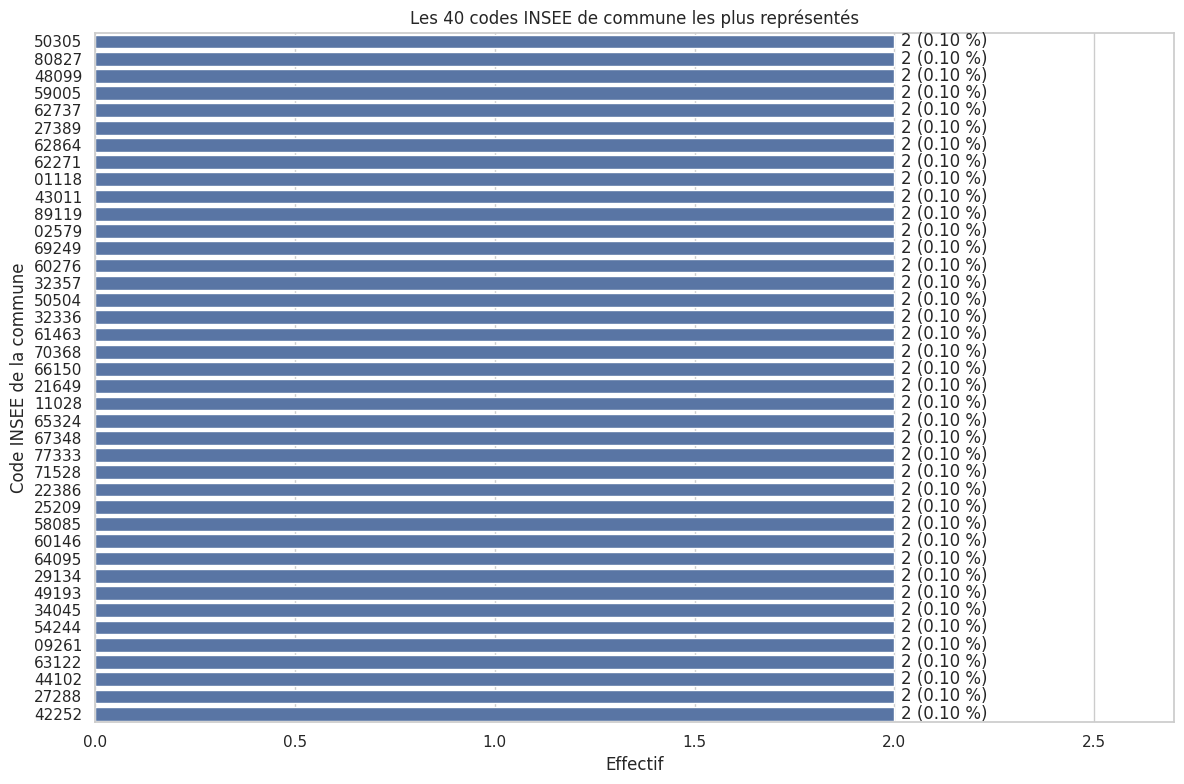

In [21]:
# Effectif de chaque code INSEE
effectifs_insee = (
    df_train["code_insee_commune"]
    .astype("string")
    .value_counts()
    .head(40)
    .sort_values()
)

plt.figure(figsize=(12, 8))

ax = sns.barplot(
    x=effectifs_insee.values,
    y=effectifs_insee.index,
)

total = len(df_train)

# Affichage des effectifs et pourcentages
for barre in ax.patches:
    effectif = int(barre.get_width())
    pourcentage = effectif / total * 100

    ax.annotate(
        f"{effectif} ({pourcentage:.2f} %)",
        (
            barre.get_width(),
            barre.get_y() + barre.get_height() / 2
        ),
        ha="left",
        va="center",
        xytext=(5, 0),
        textcoords="offset points"
    )

ax.set_xlim(
    0,
    effectifs_insee.max() * 1.35
)

plt.title(
    "Les 40 codes INSEE de commune les plus représentés"
)
plt.xlabel("Effectif")
plt.ylabel("Code INSEE de la commune")
plt.tight_layout()
plt.show()

On constate qu'au maximum les communes sont représentées **2 fois** sachant que la cardinalité vaut **1 942** et qu'il y a **58 doublons**, il y a donc un grand nombre de code qui sont représentés une seule fois.

La feature `code_insee_commune` présente une cardinalité trop élevée pour être utilisée directement au niveau communal. Elle sera donc transformée en une nouvelle feature departement, extraite à partir du code INSEE. Ce changement de granularité permet de conserver l’information géographique tout en réduisant fortement le nombre de modalités, le risque de surapprentissage et la présence de catégories inconnues lors de la prédiction.

L'extraction de cette information suivra le conception suivant, extration des 2 premier caractère (ou 3 si commence par "97" ou "98").

regardons la distribution avec cette nouvelle représentation :

,Feature,Type,Cardinalité,Valeurs manquantes,IQR,Valeurs aberrantes selon l'IQR,Valeurs dupliquées
0,departement,object,99,0,N/A,N/A,1901


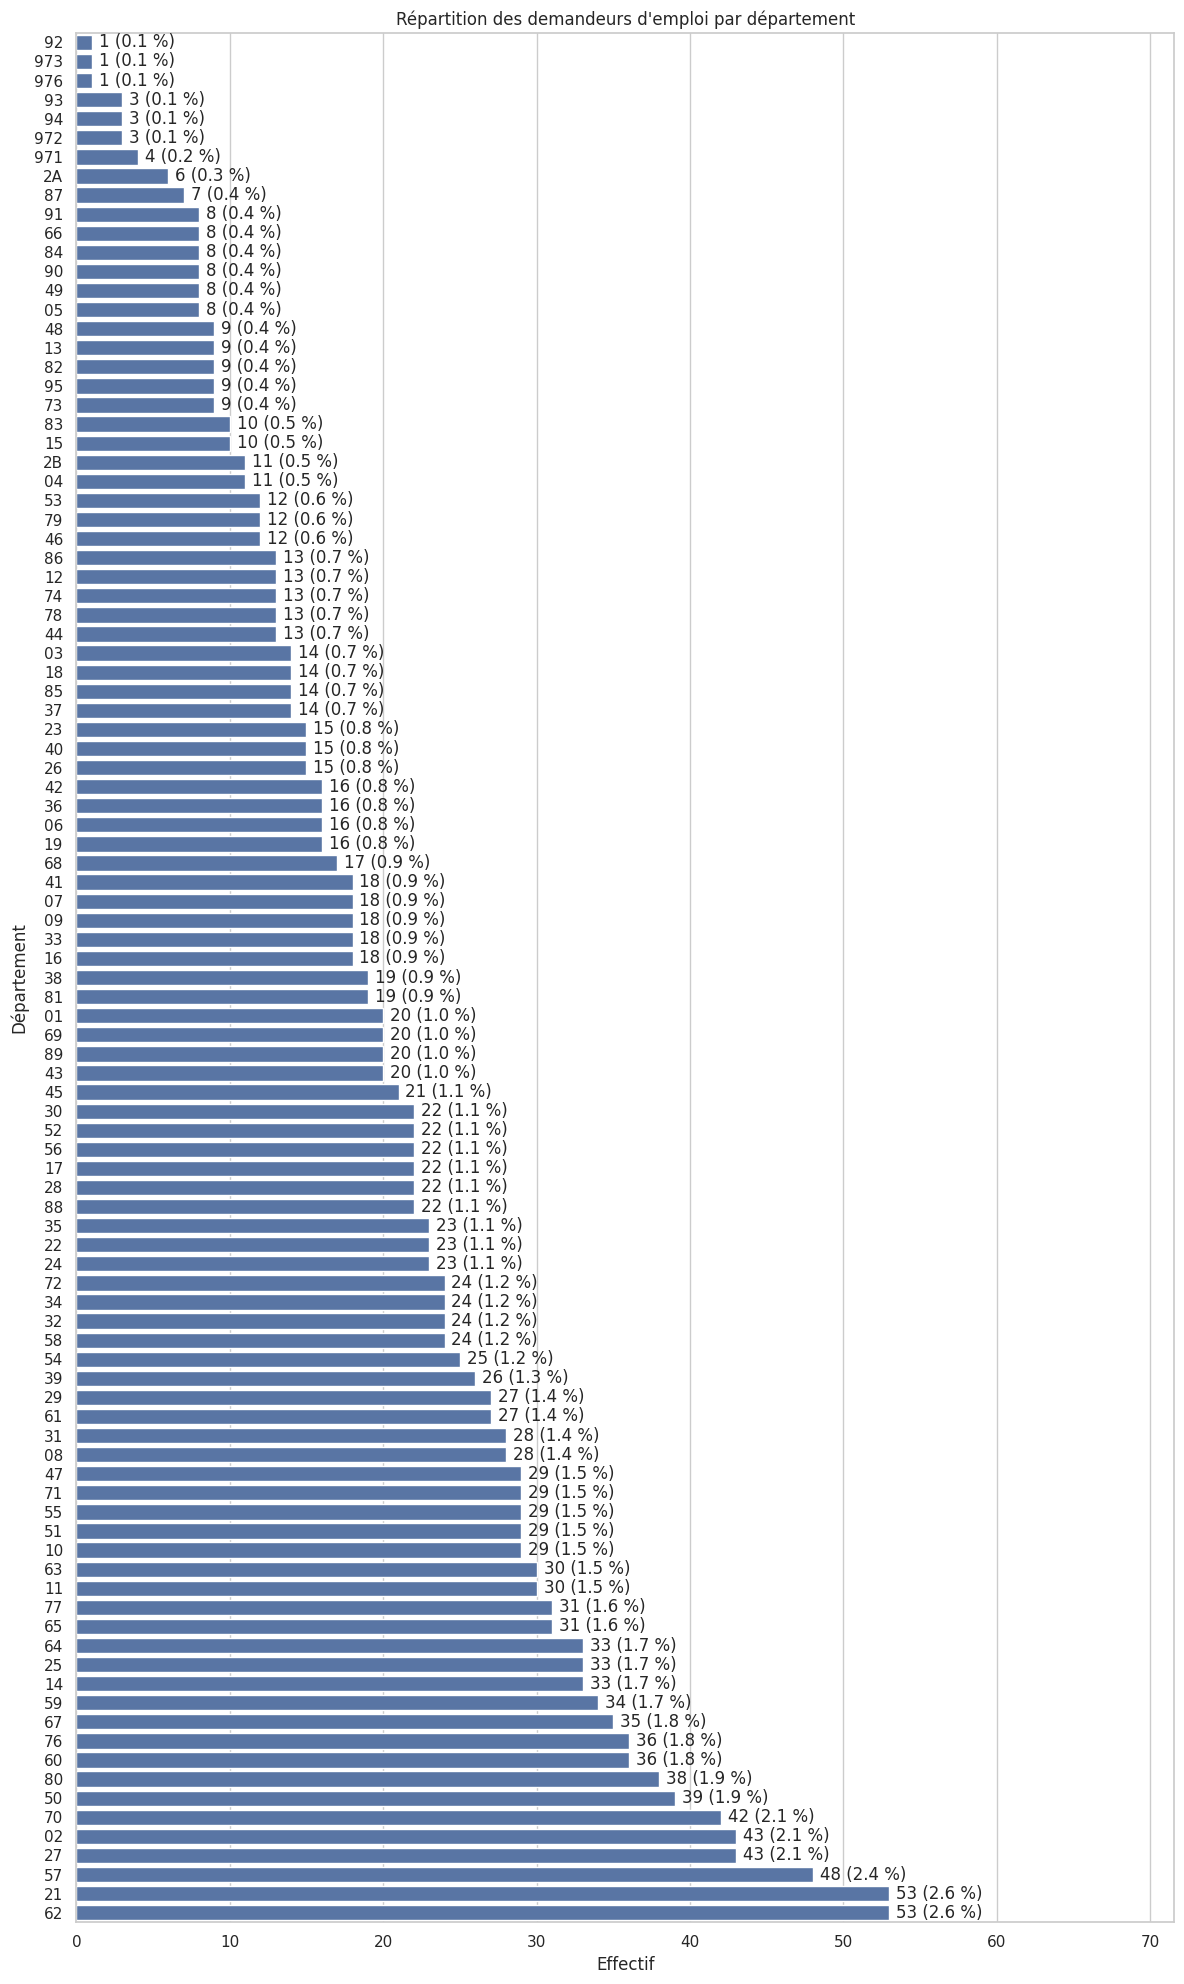

In [22]:
df_departement = df_train.copy()

df_departement["departement"] = (
    df_departement["code_insee_commune"]
    .apply(extraire_departement)
)

display( profiler(df_departement, ["departement"]))


# Calcul des effectifs par département
effectifs_departements = (
    df_departement["departement"]
    .value_counts()
    .sort_values(ascending=True)
)

# Nombre total de lignes ayant un département valide
total = effectifs_departements.sum()

plt.figure(figsize=(12, 20))

ax = sns.barplot(
    x=effectifs_departements.values,
    y=effectifs_departements.index,
    orient="h"
)

# Ajout des effectifs et pourcentages
for barre in ax.patches:
    effectif = int(barre.get_width())
    pourcentage = effectif / total * 100

    ax.annotate(
        f"{effectif} ({pourcentage:.1f} %)",
        (
            barre.get_width(),
            barre.get_y() + barre.get_height() / 2
        ),
        ha="left",
        va="center",
        xytext=(5, 0),
        textcoords="offset points"
    )

# Ajouter de l'espace pour les annotations
ax.set_xlim(
    0,
    effectifs_departements.max() * 1.35
)

plt.title(
    "Répartition des demandeurs d'emploi par département"
)
plt.xlabel("Effectif")
plt.ylabel("Département")
plt.tight_layout()
plt.show()

La distribution par département est moins équilibrée que celle observée au niveau communal, ce qui reste cohérent avec la répartition géographique des demandeurs d’emploi. Cette transformation permet surtout de réduire fortement la cardinalité de la variable, qui passe de **1 942 codes communaux** à **99 départements**, tout en conservant une information géographique exploitable par le modèle.

Actions préconisées :

| feature | **`Scénario 1`** | **`Scénario 2`** | **`Scénario 3`** | **`Scénario 4`** |
|:---:|:---:|:---:|:---:|:---:|
|`code_insee_commune`|✅ retenue</br>adaptation geographique (departement) |❌ écartée — risque de proxy géographique et discrimination indirecte|❌ écartée | ✅ retenue</br>adaptation geographique (departement) |

###  3.8 Analyse des données - feature `est_allocataire`

La variable `est_allocataire` indique si le demandeur d’emploi bénéficie ou non d’une allocation. Bien qu’elle soit actuellement stockée sous forme numérique (`0.0`, `1.0`, NaN).  Une première observation réalisée lors de l’analyse générale des données, présentée en section 3.1, met en évidence la présence de valeurs manquantes (**38**). Une stratégie de traitement doit donc être définie avant l’entraînement des modèles.

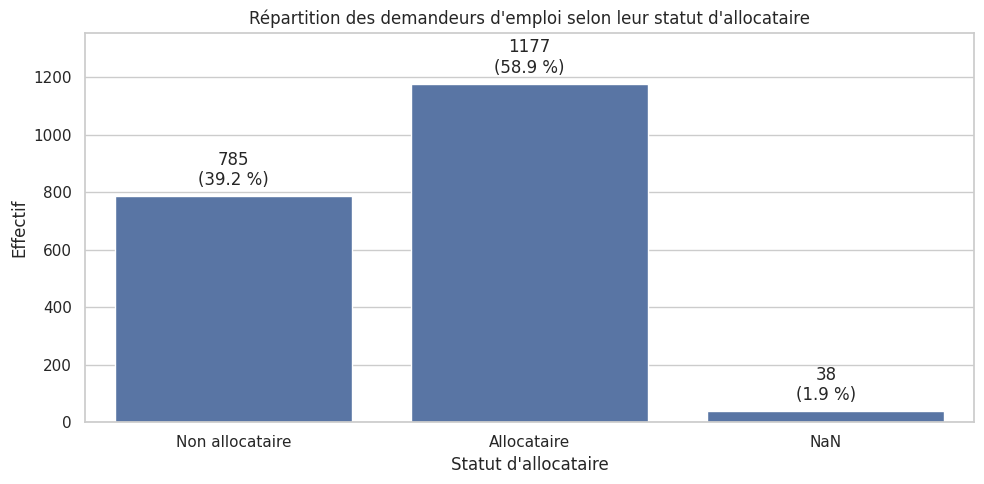

In [23]:
# Transformer les valeurs numériques en libellés explicites
allocataire_affichage = (
    df_train["est_allocataire"]
    .map({
        0: "Non allocataire",
        1: "Allocataire"
    })
    .fillna("NaN")
)

# Ordre d'affichage
ordre = [
    "Non allocataire",
    "Allocataire",
    "NaN"
]

# Calcul des effectifs
effectifs = (
    allocataire_affichage
    .value_counts()
    .reindex(ordre, fill_value=0)
)

plt.figure(figsize=(10, 5))

ax = sns.countplot(
    x=allocataire_affichage,
    order=ordre
)

# Nombre total d'observations
total = len(allocataire_affichage)

# Ajouter l'effectif et le pourcentage sur chaque barre
for barre in ax.patches:
    effectif = int(barre.get_height())
    pourcentage = effectif / total * 100

    ax.annotate(
        f"{effectif}\n({pourcentage:.1f} %)",
        (
            barre.get_x() + barre.get_width() / 2,
            effectif
        ),
        ha="center",
        va="bottom",
        xytext=(0, 5),
        textcoords="offset points"
    )

# Laisser de la place au-dessus des barres
ax.set_ylim(
    0,
    effectifs.max() * 1.15
)

plt.title(
    "Répartition des demandeurs d'emploi "
    "selon leur statut d'allocataire"
)

plt.xlabel("Statut d'allocataire")
plt.ylabel("Effectif")

plt.tight_layout()
plt.show()

Sur le jeu d'entraînement, **58,85 %** des demandeurs sont allocataires et **39,25 %** ne le sont pas. La variable contient également 38 valeurs manquantes, soit **1,90 %** des observations. Il n'est pas pertinent d'imputer ces valeurs par la modalité majoritaire, car cela reviendrait à attribuer arbitrairement un statut d'allocataire. Je conseille de créer une troisième modalité `Non renseigné` afin de conserver explicitement l'absence d'information.

Actions préconisées :

| feature | **`Scénario 1`** | **`Scénario 2`** | **`Scénario 3`** | **`Scénario 4`** |
|:---:|:---:|:---:|:---:|:---:|
|`est_allocataire`|✅ retenue</br>imputation avec Modalité `Non renseigné`|❌ écartée|❌ écartée|❌ écartée|

###  3.9 Analyse des données - feature `nationalite_hors_ue`

La variable `nationalite_hors_ue` indique si le demandeur d’emploi possède ou non une nationalité hors Union européenne. Elle est stockée sous forme numérique (0 / 1), mais il s’agit en réalité d’une variable **catégorielle binaire**. Elle ne contient aucune valeur manquante et seules les modalités 0 et 1 sont présentes. Il n’y a donc aucun traitement d’imputation à prévoir.

Actions préconisées :

| feature | **`Scénario 1`** | **`Scénario 2`** | **`Scénario 3`** | **`Scénario 4`** |
|:---:|:---:|:---:|:---:|:---:|
|`nationalite_hors_ue`|✅ retenue|❌ écartée|❌ écartée|❌ écartée|

###  3.10 Analyse des données - feature `synthese_entretien`

La variable `synthese_entretien` contient la synthèse textuelle issue de l’entretien de cadrage du demandeur d’emploi. Il s’agit donc d’une variable textuelle non structurée destinée à apporter un contexte sémantique complémentaire aux données tabulaires. Cette variable présente deux caractéristiques importantes :

- elle contient des valeurs manquantes ;
- le nombre de formulations distinctes est très faible : 9 formulations standardisées.

Ce deuxième point est important : on est davantage face à un ensemble de phrases préformatées qu’à de véritables verbatims libres.

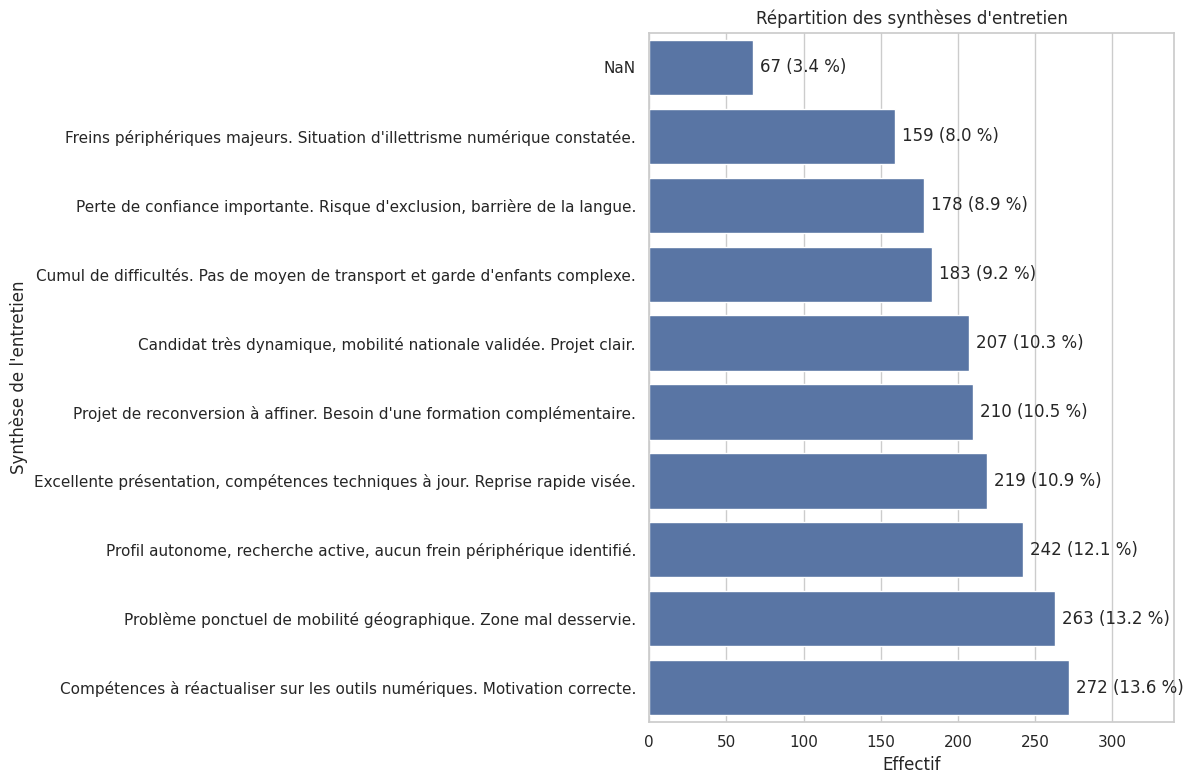

In [24]:
synthese_affichage = (
    df_train["synthese_entretien"]
    .fillna("NaN")
)

effectifs = (
    synthese_affichage
    .value_counts()
    .sort_values()
)

plt.figure(figsize=(12, 8))

ax = sns.barplot(
    x=effectifs.values,
    y=effectifs.index
)

total = len(synthese_affichage)

for barre in ax.patches:
    effectif = int(barre.get_width())
    pourcentage = effectif / total * 100

    ax.annotate(
        f"{effectif} ({pourcentage:.1f} %)",
        (
            barre.get_width(),
            barre.get_y() + barre.get_height() / 2
        ),
        ha="left",
        va="center",
        xytext=(5, 0),
        textcoords="offset points"
    )

ax.set_xlim(
    0,
    effectifs.max() * 1.25
)

plt.title(
    "Répartition des synthèses d'entretien"
)
plt.xlabel("Effectif")
plt.ylabel("Synthèse de l'entretien")

plt.tight_layout()
plt.show()

Je propose que nous imputions les 'NaN' avec une Modalité `Non renseigné`.
Comme il n'y a que 9 formulations, il faut impérativement vérifier si certaines phrases correspondent presque directement à une valeur de `classe_retour_emploi`.

In [25]:
tableau_croise_pct = pd.crosstab(
    X_train["synthese_entretien"].fillna("NaN"),
    y_train,
    normalize="index",
) * 100

display(tableau_croise_pct.round(1))

classe_retour_emploi,0,1,2
synthese_entretien,,,
"Candidat très dynamique, mobilité nationale validée. Projet clair.",66.2,25.1,8.7
Compétences à réactualiser sur les outils numériques. Motivation correcte.,14.7,79.0,6.2
Cumul de difficultés. Pas de moyen de transport et garde d'enfants complexe.,24.0,24.0,51.9
"Excellente présentation, compétences techniques à jour. Reprise rapide visée.",71.2,20.1,8.7
Freins périphériques majeurs. Situation d'illettrisme numérique constatée.,25.2,32.7,42.1
NaN,44.8,40.3,14.9
"Perte de confiance importante. Risque d'exclusion, barrière de la langue.",31.5,25.3,43.3
Problème ponctuel de mobilité géographique. Zone mal desservie.,17.1,74.1,8.7
"Profil autonome, recherche active, aucun frein périphérique identifié.",69.4,21.5,9.1


L’analyse croisée entre `synthese_entretien` et `classe_retour_emploi` met en évidence une forte relation entre certaines formulations et la classe cible. Les synthèses décrivant des profils autonomes ou dynamiques sont majoritairement associées à la classe 0, les situations nécessitant un accompagnement modéré à la classe 1, tandis que les formulations décrivant des freins importants sont davantage associées à la classe 2. La variable textuelle semble donc disposer d’un pouvoir prédictif important. Cette relation ne constitue pas une fuite de cible.

#### 3.10.1 Cadrage particulier pour le scénario 2

Pour le cas particulier du scénario 2 cadrage éthique, 4 synthèses soulignent des problèmes éthiques :

- Situation familiale exposée
  -  Avant : `Cumul de difficultés. Pas de moyen de transport et garde d'enfants complexe.`
  -  Scénario 2 : `Cumul de difficultés logistiques pouvant limiter la disponibilité et la mobilité.`
L'information opérationnelle est conservée sans révéler la situation familiale.

- Origine ou nationalité exposée
  -  Avant : `Perte de confiance importante. Risque d'exclusion, barrière de la langue.`
  -  Scénario 2 : `Besoin d'accompagnement renforcé pour la remobilisation et la communication professionnelle.` La barrière de la langue peut très facilement permettre au modèle de reconstruire indirectement une information liée à l'origine ou à la nationalité.

- L'illettrisme numérique
  -  Avant : `Freins périphériques majeurs. Situation d'illettrisme numérique constatée.`
  -  Scénario 2 : `Freins périphériques majeurs. Difficultés importantes dans l'utilisation des outils numériques.` La reformulation vise  à obtenir une donnée plus objective, moins stigmatisante et mieux définie métier.

- La géographie exposée

  -  Avant : `Problème ponctuel de mobilité géographique. Zone mal desservie.`
  -  Scénario 2 : `Difficulté ponctuelle de mobilité nécessitant un accompagnement.`

On retire autant que possible les informations permettant d'inférer situation familiale, origine/nationalité ou localisation précise.

#### 3.10.2 Conclusion imputation `synthese_entretien`

| feature | **`Scénario 1`** | **`Scénario 2`** | **`Scénario 3`** | **`Scénario 4`** |
|:---:|:---:|:---:|:---:|:---:|
|`synthese_entretien`|✅ Retenue — vectorisation TF-IDF</br> & imputation modalité `Non renseignée`|✅ Retenue — vectorisation TF-IDF</br> & imputation modalité `Non renseignée` et Cadrage particulier §3.10.1 |✅ Retenue — vectorisation TF-IDF</br> & imputation modalité `Non renseignée`|❌ écartée|

###  3.11 Analyse des données - cible `classe_retour_emploi`

En première approche, regardons la distribution de la cible sur les 3 classes proposés :

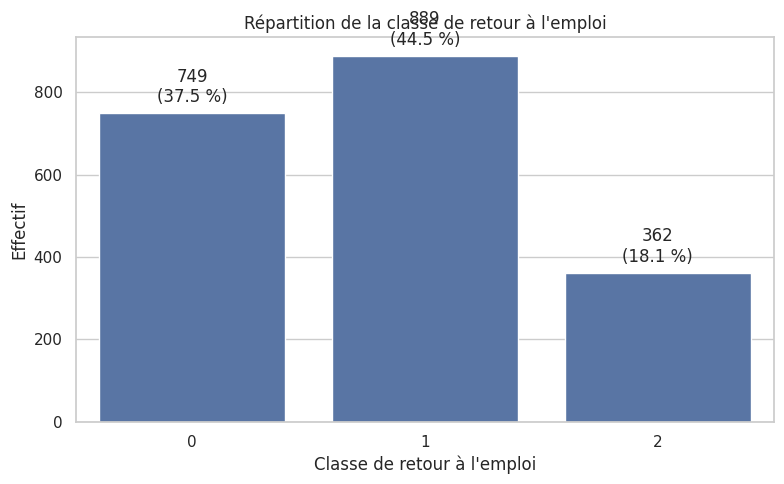

In [26]:
plt.figure(figsize=(8, 5))

ax = sns.countplot(
    x=y_train,
    order=[0, 1, 2]
)

total = len(y_train)

for barre in ax.patches:
    effectif = int(barre.get_height())
    pourcentage = effectif / total * 100

    ax.annotate(
        f"{effectif}\n({pourcentage:.1f} %)",
        (
            barre.get_x() + barre.get_width() / 2,
            effectif
        ),
        ha="center",
        va="bottom",
        xytext=(0, 5),
        textcoords="offset points"
    )

plt.title("Répartition de la classe de retour à l'emploi")
plt.xlabel("Classe de retour à l'emploi")
plt.ylabel("Effectif")

plt.tight_layout()
plt.show()

La distribution de la variable cible présente un déséquilibre modéré. La classe `1` est majoritaire avec environ **44,5 %** des observations, suivie de la classe `0` avec **37,5 %**, tandis que la classe `2`, correspondant aux trajectoires de retour à l’emploi les plus longues, est minoritaire avec environ **18 %** des observations.

Cette sous-représentation peut conduire le modèle à privilégier les classes majoritaires et à moins bien détecter les individus appartenant à la classe `2`. Une attention particulière devra donc être portée au rappel de cette classe ainsi qu’au F1-score macro.

Pour l’évaluation, **une validation croisée stratifiée à 5 folds sera utilisée afin de conserver**, dans chaque fold, des proportions de classes proches de celles du dataset initial.

###  3.12 Analyse bi-variée 

Dans cette analyse bi-varié, identifions les features qui ont une forte corrélation avec la cible pour comprendre le métier et détecter si il n'existe pas de biais. L'algorithme choisi pour cette analyse se fera par rapport au type (qualitatif ou quantitatif) de la feature :

| Feature| Type| Mesure avec `classe_retour_emploi`|
| --- |:---:|:---:|
| `age`| quantitative| Spearman|
| `anciennete_poste_ans` | quantitative| Spearman|
| `niveau_diplome`| qualitative| V de Cramér|
| `code_rome_vise`| qualitative| V de Cramér|
| `code_insee_commune`| qualitative| V de Cramér|
| `est_allocataire`| qualitative| V de Cramér|
| `nationalite_hors_ue`| qualitative| V de Cramér|
| `synthese_entretien`| qualitative| V de Cramér|

#### 3.12.1 Analyse Spearman

In [27]:
resultats = []

for feature in ["age", "anciennete_poste_ans"]:

    rho, p_value = spearmanr(
        df_train[feature],
        y_train,
        nan_policy="omit"
    )

    resultats.append({
        "feature": feature,
        "spearman_rho": rho,
        "p_value": p_value
    })

df_spearman = pd.DataFrame(resultats)

display(
    df_spearman.round(4)
)

,feature,spearman_rho,p_value
0,age,0.2461,0.0000
1,anciennete_poste_ans,0.0398,0.0748


L’analyse de Spearman met en évidence une association positive faible à modérée entre `age` et `classe_retour_emploi` (rho = 0,24, p < 0,001). Les classes étant ordonnées de 0 à 2, ce résultat suggère que l’augmentation de l’âge est associée à des trajectoires de retour à l’emploi plus longues. La relation reste toutefois limitée et l’âge ne peut pas être considéré comme un prédicteur suffisant à lui seul.

À l’inverse, `anciennete_poste_ans` présente une corrélation quasi nulle avec la cible (rho = 0,039, p = 0,0748). Bien que la relation soit statistiquement significative ~ 4 %, son intensité est trop faible pour conclure à une association substantielle.

==> **l’âge contient du signal prédictif**, donc le retirer peut éventuellement coûter un peu en performance.

#### 3.12.1 Analyse V de Cramèr

In [28]:
features_qualitatives = [

]

resultats_cramer = []

for feature in FEATURES_QUALITATIVES:

    if (feature == "code_insee_commune"):
        v = cramers_v(df_train["code_insee_commune"].apply(
            extraire_departement
            ),
            y_train
        )
    else:
        v = cramers_v(
            df_train[feature].fillna("Non renseigné"),
            y_train
        )
       
    resultats_cramer.append({
        "feature": feature,
        "v_cramer": v
    })

df_cramer = pd.DataFrame(resultats_cramer)

df_cramer = (
    df_cramer
    .sort_values(
        "v_cramer",
        ascending=False
    )
)

display(
    df_cramer.round(4)
)

,feature,v_cramer
5,synthese_entretien,0.4714
0,niveau_diplome,0.2852
1,code_rome_vise,0.2635
3,code_insee_commune,0.2442
4,nationalite_hors_ue,0.2330
2,est_allocataire,0.0236


L’analyse bivariée par le V de Cramér met en évidence des niveaux d’association différents entre les variables qualitatives et la cible `classe_retour_emploi`. La variable `synthese_entretien` présente l’association la plus importante avec un V de Cramér de 0,4714.

Les variables `niveau_diplome` (0,2852), `code_rome_vise` (0,2635) et la variable géographique `code_insee_commune`, préalablement agrégée au niveau départemental (0,2442), présentent des associations plus modérées mais non négligeables avec la cible. Elles peuvent donc apporter une information utile au modèle.

La variable `nationalite_hors_ue` présente également une association mesurable avec la cible (0,2330). Ce résultat doit être interprété avec prudence : bien que cette variable puisse apporter du signal prédictif, elle présente un risque important de discrimination et reste écartée du scénario éthique.

À l’inverse, `est_allocataire` présente un V de Cramér très faible (0,0236), indiquant une association bivariée quasi nulle avec la cible.

###  3.13 📝 Synthèse de l'exploration des données

La tableau ci-dessous reprend pour chacune des features les stratégies à adopter en fonction des scénarios.

| feature | **`Scénario 1`**</br> Reference | **`Scénario 2`**</br> Ethique | **`Scénario 3`**</br> Texte seul | **`Scénario 4`**</br> Tabulaire seul |
|:---:|:---:|:---:|:---:|:---:|
|`usager_id`|❌ écartée|❌ écartée|❌ écartée|❌ écartée|
| `age` | ✅ conservée</br>médiane + feature `age_manquant`</br>exclusion des incohérences métier | ❌ écartée | ❌ écartée | ✅ conservée</br>médiane + feature `age_manquant`</br>exclusion des incohérences métier |
|`niveau_diplome`|✅ retenue</br>imputation avec Modalité `Non renseigné`|✅ retenue</br>imputation avec Modalité `Non renseigné`|❌ écartée|✅ retenue</br>imputation avec Modalité `Non renseigné` |
|`anciennete_poste_ans`|✅ retenue|✅ retenue|❌ écartée|✅ retenue|
|`code_rome_vise`|✅ retenue|✅ retenue|❌ écartée|❌ écartée|
|`code_insee_commune`|✅ retenue</br>adaptation geographique (**new feature** departement) |❌ écartée |❌ écartée | ✅ retenue</br>adaptation geographique (**new feature** departement) |
|`est_allocataire`|✅ retenue</br>imputation avec Modalité `Non renseigné`|❌ écartée|❌ écartée|❌ écartée|
|`nationalite_hors_ue`|✅ retenue|❌ écartée|❌ écartée|❌ écartée|
|`synthese_entretien`|✅ Retenue — vectorisation TF-IDF</br> & modalité `Non renseignée`|✅ Retenue — vectorisation TF-IDF</br> & modalité `Non renseignée` et **Cadrage particulier §3.10.1** |✅ Retenue — vectorisation TF-IDF</br> & modalité `Non renseignée`|❌ écartée|

## 4. Préparation des données

In [29]:
# Processeur pour le Scénarion 1
display(preprocessor_s1)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('age', ...), ('num', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e

In [30]:
# Processeur pour le Scénarion 2
display(preprocessor_s2)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e

In [31]:
# Processeur pour le Scénarion 3
display(preprocessor_s3)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('text', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""{feature_n

In [32]:
# Processeur pour le Scénarion 4
display(preprocessor_s4)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('age', ...), ('num', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e

## 5. Analyse comparée des scénarios

Pour rappel, conformément aux critères de succès définis au §1.4, l’évaluation des modèles se focalise principalement sur deux indicateurs : le **rappel de la classe 2**, afin de limiter les erreurs critiques sur les usagers à risque de retour à l’emploi de longue durée, et le **F1-score macro**, afin d’évaluer de manière équilibrée les performances globales sur les trois classes.

### 5.1 Approche globale

Dans une première phase, les quatre scénarios sont évalués à l’aide de quatre modèles de classification couramment utilisés : `LogisticRegression`, `LinearSVC`, `RandomForest` et `XGBoost`.

Cette première comparaison est réalisée avec des hyperparamètres standards, sans optimisation fine, afin d’obtenir un benchmark initial homogène et comparable entre les scénarios.

Les modèles les plus prometteurs seront ensuite approfondis dans une seconde phase par optimisation de leurs hyperparamètres, en privilégiant le rappel de la classe 2 et le F1-score macro.

In [33]:
MODELES = {
    "LogisticRegression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),

    "LinearSVC": LinearSVC(
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),

    "RandomForest": RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
}


# Distribution de la cible déséquilibrée
# donc validation croisée stratifiée cf. §3.11
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)


SCORING = {
    "accuracy": "accuracy",
    "f1_macro": "f1_macro",
    "f1_weighted": "f1_weighted",
    "recall_macro": "recall_macro",

    "recall_classe_2": make_scorer(
        recall_score,
        labels=[2],
        average="macro",
        zero_division=0
    )
}


SCENARIOS = {
    "Scenario 1 - Multimodal": preprocessor_s1,
    "Scenario 2 - Ethique": preprocessor_s2,
    "Scenario 3 - NLP": preprocessor_s3,
    "Scenario 4 - Tabulaire": preprocessor_s4
}


resultats = []


for nom_scenario, preprocessor in SCENARIOS.items():

    for nom_modele, modele in MODELES.items():

        pipeline = Pipeline([
            ("preprocessor", preprocessor),
            ("model", modele)
        ])

        # ------------------------------------------------------
        # 1. Validation croisée
        # ------------------------------------------------------

        scores = cross_validate(
            pipeline,
        
            X_train_age if nom_scenario in [
                "Scenario 1 - Multimodal",
                "Scenario 4 - Tabulaire"
            ] else X_train,
        
            y_train_age if nom_scenario in [
                "Scenario 1 - Multimodal",
                "Scenario 4 - Tabulaire"
            ] else y_train,
        
            cv=cv,
            scoring=SCORING,
            n_jobs=-1
        )


        # ------------------------------------------------------
        # 2. Mesure du temps d'inférence
        #
        # On entraîne le pipeline sur tout le train uniquement
        # pour mesurer le temps nécessaire à une prédiction.
        # ------------------------------------------------------
        # N.B : exclusion des ages incohérents uniquement pour le scénario 1 et 4
        pipeline.fit(
            X_train_age if nom_scenario in [
                "Scenario 1 - Multimodal",
                "Scenario 4 - Tabulaire"
            ] else X_train,
            y_train_age if nom_scenario in [
                "Scenario 1 - Multimodal",
                "Scenario 4 - Tabulaire"
            ] else y_train
        )


        temps_inference = []

        # 100 observations suffisent pour obtenir une estimation
        # raisonnable de la latence
        X_latence = X_train.iloc[:100]


        for i in range(len(X_latence)):

            observation = X_latence.iloc[[i]]

            debut = time.perf_counter()

            pipeline.predict(
                observation
            )

            fin = time.perf_counter()

            temps_inference.append(
                (fin - debut) * 1000
            )


        inference_ms = np.mean(
            temps_inference
        )

        inference_p95_ms = np.percentile(
            temps_inference,
            95
        )


        # ------------------------------------------------------
        # 3. Sauvegarde des résultats
        # ------------------------------------------------------

        resultats.append({

            "scenario": nom_scenario,
            "modele": nom_modele,

            "accuracy": scores[
                "test_accuracy"
            ].mean(),

            "f1_macro": scores[
                "test_f1_macro"
            ].mean(),

            "f1_weighted": scores[
                "test_f1_weighted"
            ].mean(),

            "recall_macro": scores[
                "test_recall_macro"
            ].mean(),

            "recall_classe_2": scores[
                "test_recall_classe_2"
            ].mean(),

            "f1_macro_std": scores[
                "test_f1_macro"
            ].std(),

            "inference_ms": inference_ms,
            "inference_p95_ms": inference_p95_ms
        })


# ============================================================
# Création du DataFrame de résultats
# ============================================================

df_resultats = pd.DataFrame(
    resultats
)


df_resultats_affichage = (
    df_resultats
    .sort_values(
        by=[
            "scenario",
            "f1_macro"
        ],
        ascending=[
            True,
            False
        ]
    )
    .reset_index(
        drop=True
    )
)


# ============================================================
# Mise en forme
# ============================================================

def mettre_max_en_gras(colonne):

    max_val = colonne.max()

    return [
        "font-weight: bold"
        if valeur == max_val
        else ""
        for valeur in colonne
    ]


def mettre_min_en_gras(colonne):

    min_val = colonne.min()

    return [
        "font-weight: bold"
        if valeur == min_val
        else ""
        for valeur in colonne
    ]


display(
    df_resultats_affichage
    .style
    .hide(axis="index")
    .format({
        "recall_classe_2": "{:.4f}",
        "f1_macro_std": "{:.4f}",
        "inference_ms": "{:.2f}",
        "accuracy": "{:.4f}",
        "f1_macro": "{:.4f}",
        "f1_weighted": "{:.4f}",
        "recall_macro": "{:.4f}",
        "inference_p95_ms": "{:.2f}"
    })
    .apply(
        mettre_max_en_gras,
        subset=[
            "accuracy",
            "f1_macro",
            "f1_weighted",
            "recall_macro",
            "recall_classe_2"
        ]
    )
    .apply(
        mettre_min_en_gras,
        subset=[
            "f1_macro_std",
            "inference_ms",
            "inference_p95_ms"
        ]
    )
)

scenario,modele,accuracy,f1_macro,f1_weighted,recall_macro,recall_classe_2,f1_macro_std,inference_ms,inference_p95_ms
Scenario 1 - Multimodal,XGBoost,0.7216,0.7045,0.7203,0.6984,0.5936,0.0154,12.57,18.50
Scenario 1 - Multimodal,RandomForest,0.6923,0.6701,0.6908,0.6665,0.5508,0.0352,64.97,71.60
Scenario 1 - Multimodal,LogisticRegression,0.6772,0.6627,0.6795,0.6793,0.6715,0.0312,7.31,12.87
Scenario 1 - Multimodal,LinearSVC,0.6730,0.6541,0.6747,0.6627,0.6053,0.0301,6.25,7.41
Scenario 2 - Ethique,LogisticRegression,0.6640,0.6486,0.6690,0.6686,0.6770,0.0145,4.42,6.84
Scenario 2 - Ethique,LinearSVC,0.6655,0.6450,0.6696,0.6571,0.6106,0.0125,3.61,4.11
Scenario 2 - Ethique,XGBoost,0.6460,0.6142,0.6436,0.6111,0.4589,0.0254,12.44,19.65
Scenario 2 - Ethique,RandomForest,0.6325,0.6041,0.6305,0.5996,0.4616,0.0170,64.93,85.16
Scenario 3 - NLP,LogisticRegression,0.6515,0.6350,0.6576,0.6535,0.6605,0.0166,1.69,2.80
Scenario 3 - NLP,LinearSVC,0.6515,0.6350,0.6576,0.6535,0.6605,0.0166,1.19,1.52


En synthèse des résultats obtenus et au regard des critères de succès définis au §1.4, les quatre scénarios peuvent être comparés comme suit.

| Scenario | Critère C1 — Rappel classe 2 | Critère C2 — F1 macro | Critère C3 — Temps d'inférence | Décision |
|---|---|---|---|---|
| `Scenario 1 - Multimodal` | `LogisticRegression` se démarque avec un rappel de la classe 2 de **0.6715**, deuxième meilleur résultat global | Meilleur F1 macro de l'ensemble des scénarios avec **0.7045** obtenu par `XGBoost` | Très bonnes performances opérationnelles ; les modèles linéaires restent autour de quelques millisecondes | **Scénario de référence pour la performance globale.** `XGBoost` est le meilleur candidat pour C2, tandis que `LogisticRegression` est plus pertinent pour C1 |
| `Scenario 2 - Ethique` | Meilleur résultat global sur C1 avec `LogisticRegression` : **0.6770** | F1 macro maximal de **0.6486** avec `LogisticRegression`, inférieur au scénario 1 et au seuil cible fixé | Très bonnes performances opérationnelles ; les modèles linéaires restent autour de quelques millisecondes | **Scénario particulièrement intéressant pour un usage réel.** `LogisticRegression` offre le meilleur compromis entre éthique, rappel de la classe 2 et performance globale |
| `Scenario 3 - NLP` | Rappel classe 2 de **0.6605** pour tous les modèles | F1 macro identique de **0.6350** pour les quatre modèles | Excellent temps d'inférence, notamment `LinearSVC` à environ **1.56 ms** | **Scénario utile pour le diagnostic et l'étude de robustesse NLP**, mais les résultats identiques montrent que le texte est fortement standardisé et se comporte presque comme une variable catégorielle |
| `Scenario 4 - Tabulaire` | Meilleur rappel classe 2 de **0.5554** avec `LogisticRegression` | Meilleur F1 macro de **0.5468** avec `XGBoost` | Temps d'inférence globalement satisfaisant | **Scénario nettement moins performant.** Il sert surtout à mesurer l'apport du contexte textuel et confirme que le texte contribue fortement aux performances |

Aucun scénario ne satisfait à ce stade les seuils cibles définis pour C1 (recall classe 2 > 0,95) et C2 (F1 macro ≥ 0,75). En revanche, le critère C3 est globalement respecté. Les travaux d’optimisation porteront donc en priorité sur `XGBoost` dans le scénario 1 et `LogisticRegression` dans le scénario 2.

### 5.2 Focus sur Scenario 1 - XGBoos (Benchmark de référence)


In [34]:
pipeline_xgb_s1 = Pipeline([
    ("preprocessor", preprocessor_s1),
    (
        "model",
        XGBClassifier(
            objective="multi:softprob",
            eval_metric="mlogloss",
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    )
])


SCORING_XGB = {
    "f1_macro": "f1_macro",

    "recall_classe_2": make_scorer(
        recall_score,
        labels=[2],
        average="macro",
        zero_division=0
    )
}


param_grid_xgb = {

    # Nombre d'arbres
    "model__n_estimators": [
        200,
        300,
        500
    ],

    # Profondeur
    "model__max_depth": [
        3,
        5,
        7
    ],

    # Vitesse d'apprentissage
    "model__learning_rate": [
        0.03,
        0.05,
        0.1
    ],

    # Régularisation / robustesse
    "model__subsample": [
        0.8,
        1.0
    ],

    "model__colsample_bytree": [
        0.8,
        1.0
    ],

    # Régularisation L1
    "model__reg_alpha": [
        0,
        0.1,
        1
    ],

    # Régularisation L2
    "model__reg_lambda": [
        1,
        5,
        10
    ],

    # Rend l'arbre plus conservateur
    "model__min_child_weight": [
        1,
        3,
        5
    ]
}


grid_xgb = GridSearchCV(
    estimator=pipeline_xgb_s1,
    param_grid=param_grid_xgb,
    scoring=SCORING_XGB,

    # On refit sur le F1 macro,
    # car XGBoost est ici notre candidat principal pour C2
    refit="f1_macro",

    cv=cv,
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)


grid_xgb.fit(
    X_train_age,
    y_train_age
)


print("Meilleurs paramètres XGBoost :")
print(
    grid_xgb.best_params_
)

print("\nMeilleur F1 macro CV :")
print(
    round(
        grid_xgb.best_score_,
        4
    )
)

df_grid_xgb = pd.DataFrame(
    grid_xgb.cv_results_
)


colonnes = [
    "params",
    "mean_test_f1_macro",
    "mean_test_recall_classe_2",
    "std_test_f1_macro"
]


df_grid_xgb_affichage = (
    df_grid_xgb[
        colonnes
    ]
    .sort_values(
        by=[
            "mean_test_f1_macro",
            "mean_test_recall_classe_2"
        ],
        ascending=[
            False,
            False
        ]
    )
)


display(
    df_grid_xgb_affichage
    .head(20)
    .style
    .hide(axis="index")
    .format({
        "mean_test_f1_macro": "{:.4f}",
        "mean_test_recall_classe_2": "{:.4f}",
        "std_test_f1_macro": "{:.4f}"
    })
)

Fitting 5 folds for each of 2916 candidates, totalling 14580 fits
[CV] END model__colsample_bytree=0.8, model__learning_rate=0.03, model__max_depth=3, model__min_child_weight=1, model__n_estimators=200, model__reg_alpha=0, model__reg_lambda=1, model__subsample=1.0; total time=   0.5s
[CV] END model__colsample_bytree=0.8, model__learning_rate=0.03, model__max_depth=3, model__min_child_weight=1, model__n_estimators=200, model__reg_alpha=0, model__reg_lambda=5, model__subsample=1.0; total time=   0.5s
[CV] END model__colsample_bytree=0.8, model__learning_rate=0.03, model__max_depth=3, model__min_child_weight=1, model__n_estimators=200, model__reg_alpha=0, model__reg_lambda=10, model__subsample=1.0; total time=   0.6s
[CV] END model__colsample_bytree=0.8, model__learning_rate=0.03, model__max_depth=3, model__min_child_weight=1, model__n_estimators=200, model__reg_alpha=0.1, model__reg_lambda=1, model__subsample=1.0; total time=   0.6s
[CV] END model__colsample_bytree=0.8, model__learning_r

params,mean_test_f1_macro,mean_test_recall_classe_2,std_test_f1_macro
"{'model__colsample_bytree': 1.0, 'model__learning_rate': 0.05, 'model__max_depth': 5, 'model__min_child_weight': 3, 'model__n_estimators': 300, 'model__reg_alpha': 0.1, 'model__reg_lambda': 10, 'model__subsample': 1.0}",0.7197,0.6108,0.0115
"{'model__colsample_bytree': 1.0, 'model__learning_rate': 0.03, 'model__max_depth': 5, 'model__min_child_weight': 3, 'model__n_estimators': 500, 'model__reg_alpha': 0, 'model__reg_lambda': 10, 'model__subsample': 1.0}",0.7189,0.6080,0.0115
"{'model__colsample_bytree': 1.0, 'model__learning_rate': 0.03, 'model__max_depth': 5, 'model__min_child_weight': 3, 'model__n_estimators': 500, 'model__reg_alpha': 0.1, 'model__reg_lambda': 10, 'model__subsample': 1.0}",0.7188,0.6109,0.0122
"{'model__colsample_bytree': 0.8, 'model__learning_rate': 0.05, 'model__max_depth': 5, 'model__min_child_weight': 3, 'model__n_estimators': 200, 'model__reg_alpha': 1, 'model__reg_lambda': 1, 'model__subsample': 1.0}",0.7178,0.6109,0.0133
"{'model__colsample_bytree': 1.0, 'model__learning_rate': 0.05, 'model__max_depth': 5, 'model__min_child_weight': 3, 'model__n_estimators': 300, 'model__reg_alpha': 0, 'model__reg_lambda': 10, 'model__subsample': 1.0}",0.7176,0.6052,0.0139
"{'model__colsample_bytree': 1.0, 'model__learning_rate': 0.03, 'model__max_depth': 5, 'model__min_child_weight': 3, 'model__n_estimators': 200, 'model__reg_alpha': 0.1, 'model__reg_lambda': 5, 'model__subsample': 1.0}",0.7174,0.5791,0.0141
"{'model__colsample_bytree': 1.0, 'model__learning_rate': 0.03, 'model__max_depth': 5, 'model__min_child_weight': 3, 'model__n_estimators': 500, 'model__reg_alpha': 0.1, 'model__reg_lambda': 5, 'model__subsample': 1.0}",0.7171,0.6080,0.0182
"{'model__colsample_bytree': 1.0, 'model__learning_rate': 0.03, 'model__max_depth': 5, 'model__min_child_weight': 3, 'model__n_estimators': 500, 'model__reg_alpha': 0, 'model__reg_lambda': 5, 'model__subsample': 1.0}",0.7170,0.6079,0.0178
"{'model__colsample_bytree': 1.0, 'model__learning_rate': 0.03, 'model__max_depth': 5, 'model__min_child_weight': 3, 'model__n_estimators': 300, 'model__reg_alpha': 0, 'model__reg_lambda': 1, 'model__subsample': 1.0}",0.7165,0.5850,0.0228
"{'model__colsample_bytree': 0.8, 'model__learning_rate': 0.03, 'model__max_depth': 5, 'model__min_child_weight': 3, 'model__n_estimators': 300, 'model__reg_alpha': 0.1, 'model__reg_lambda': 5, 'model__subsample': 1.0}",0.7161,0.6023,0.0166


In [35]:
df_grid_xgb = pd.DataFrame(
    grid_xgb.cv_results_
)

df_compromis_xgb = (
    df_grid_xgb[
        df_grid_xgb["mean_test_f1_macro"] >= 0.70
    ]
    .sort_values(
        by=[
            "mean_test_recall_classe_2",
            "mean_test_f1_macro"
        ],
        ascending=[
            False,
            False
        ]
    )
)

display(
    df_compromis_xgb[
        [
            "params",
            "mean_test_f1_macro",
            "mean_test_recall_classe_2",
            "std_test_f1_macro"
        ]
    ]
    .head(20)
    .style
    .hide(axis="index")
    .format({
        "mean_test_f1_macro": "{:.4f}",
        "mean_test_recall_classe_2": "{:.4f}",
        "std_test_f1_macro": "{:.4f}"
    })
)

params,mean_test_f1_macro,mean_test_recall_classe_2,std_test_f1_macro
"{'model__colsample_bytree': 1.0, 'model__learning_rate': 0.03, 'model__max_depth': 5, 'model__min_child_weight': 3, 'model__n_estimators': 500, 'model__reg_alpha': 0.1, 'model__reg_lambda': 10, 'model__subsample': 1.0}",0.7188,0.6109,0.0122
"{'model__colsample_bytree': 0.8, 'model__learning_rate': 0.05, 'model__max_depth': 5, 'model__min_child_weight': 3, 'model__n_estimators': 200, 'model__reg_alpha': 1, 'model__reg_lambda': 1, 'model__subsample': 1.0}",0.7178,0.6109,0.0133
"{'model__colsample_bytree': 1.0, 'model__learning_rate': 0.05, 'model__max_depth': 5, 'model__min_child_weight': 3, 'model__n_estimators': 500, 'model__reg_alpha': 0, 'model__reg_lambda': 5, 'model__subsample': 1.0}",0.7150,0.6109,0.0202
"{'model__colsample_bytree': 1.0, 'model__learning_rate': 0.05, 'model__max_depth': 5, 'model__min_child_weight': 3, 'model__n_estimators': 300, 'model__reg_alpha': 0.1, 'model__reg_lambda': 10, 'model__subsample': 1.0}",0.7197,0.6108,0.0115
"{'model__colsample_bytree': 1.0, 'model__learning_rate': 0.05, 'model__max_depth': 5, 'model__min_child_weight': 3, 'model__n_estimators': 500, 'model__reg_alpha': 0.1, 'model__reg_lambda': 10, 'model__subsample': 1.0}",0.7150,0.6108,0.0142
"{'model__colsample_bytree': 0.8, 'model__learning_rate': 0.05, 'model__max_depth': 5, 'model__min_child_weight': 3, 'model__n_estimators': 300, 'model__reg_alpha': 0, 'model__reg_lambda': 5, 'model__subsample': 1.0}",0.7128,0.6081,0.0155
"{'model__colsample_bytree': 1.0, 'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__min_child_weight': 3, 'model__n_estimators': 300, 'model__reg_alpha': 0, 'model__reg_lambda': 1, 'model__subsample': 0.8}",0.7128,0.6081,0.0173
"{'model__colsample_bytree': 0.8, 'model__learning_rate': 0.05, 'model__max_depth': 5, 'model__min_child_weight': 3, 'model__n_estimators': 300, 'model__reg_alpha': 0, 'model__reg_lambda': 10, 'model__subsample': 1.0}",0.7142,0.6080,0.0178
"{'model__colsample_bytree': 1.0, 'model__learning_rate': 0.03, 'model__max_depth': 5, 'model__min_child_weight': 3, 'model__n_estimators': 500, 'model__reg_alpha': 0, 'model__reg_lambda': 10, 'model__subsample': 1.0}",0.7189,0.6080,0.0115
"{'model__colsample_bytree': 1.0, 'model__learning_rate': 0.03, 'model__max_depth': 5, 'model__min_child_weight': 3, 'model__n_estimators': 500, 'model__reg_alpha': 0.1, 'model__reg_lambda': 5, 'model__subsample': 1.0}",0.7171,0.6080,0.0182


### 5.3 Focus sur Scenario 2 - LogisticRegression

In [36]:
# ============================================================
# Pipeline LogisticRegression - Scénario 2
# ============================================================

pipeline_lr_s2 = Pipeline([
    ("preprocessor", preprocessor_s2),
    (
        "model",
        LogisticRegression(
            max_iter=3000,
            random_state=RANDOM_STATE
        )
    )
])


# ============================================================
# Métriques
# ============================================================

SCORING_LR = {
    "f1_macro": "f1_macro",

    "recall_classe_2": make_scorer(
        recall_score,
        labels=[2],
        average="macro",
        zero_division=0
    )
}


# ============================================================
# Grille d'hyperparamètres
# ============================================================

param_grid_lr = {
    "model__C": [
        0.01,
        0.05,
        0.1,
        0.5,
        1,
        2,
        5,
        10,
        50
    ],

    "model__class_weight": [
        None,
        "balanced",
        {0: 1, 1: 1, 2: 1.5},
        {0: 1, 1: 1, 2: 2},
        {0: 1, 1: 1, 2: 3}
    ],

    "model__solver": [
        "lbfgs",
        "saga"
    ]
}


# ============================================================
# GridSearchCV
# ============================================================

grid_lr_s2 = GridSearchCV(
    estimator=pipeline_lr_s2,
    param_grid=param_grid_lr,
    scoring=SCORING_LR,

    # Le meilleur modèle sklearn est d'abord déterminé
    # selon le F1 macro
    refit="f1_macro",

    cv=cv,
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)


grid_lr_s2.fit(
    X_train,
    y_train
)


# ============================================================
# Meilleur résultat selon le F1 macro
# ============================================================

print("Meilleurs paramètres LogisticRegression S2 :")
print(
    grid_lr_s2.best_params_
)

print("\nMeilleur F1 macro CV :")
print(
    round(
        grid_lr_s2.best_score_,
        4
    )
)

best_index = grid_lr_s2.best_index_

print("\nRecall classe 2 associé :")
print(
    round(
        grid_lr_s2.cv_results_[
            "mean_test_recall_classe_2"
        ][best_index],
        4
    )
)


# ============================================================
# Analyse du compromis C1 / C2
#
# C1 : maximiser le rappel de la classe 2
# C2 : conserver un F1 macro acceptable
# ============================================================

df_grid_lr_s2 = pd.DataFrame(
    grid_lr_s2.cv_results_
)

df_compromis = (
    df_grid_lr_s2[
        df_grid_lr_s2["mean_test_f1_macro"] >= 0.64
    ]
    .sort_values(
        by=[
            "mean_test_recall_classe_2",
            "mean_test_f1_macro"
        ],
        ascending=[
            False,
            False
        ]
    )
)


display(
    df_compromis[
        [
            "params",
            "mean_test_f1_macro",
            "mean_test_recall_classe_2",
            "std_test_f1_macro"
        ]
    ]
    .head(20)
    .style
    .hide(axis="index")
    .format({
        "mean_test_f1_macro": "{:.4f}",
        "mean_test_recall_classe_2": "{:.4f}",
        "std_test_f1_macro": "{:.4f}"
    })
)

Fitting 5 folds for each of 90 candidates, totalling 450 fits

[CV] END model__colsample_bytree=1.0, model__learning_rate=0.1, model__max_depth=7, model__min_child_weight=3, model__n_estimators=300, model__reg_alpha=1, model__reg_lambda=5, model__subsample=0.8; total time=   1.9s
[CV] END model__colsample_bytree=1.0, model__learning_rate=0.1, model__max_depth=7, model__min_child_weight=3, model__n_estimators=300, model__reg_alpha=1, model__reg_lambda=10, model__subsample=1.0; total time=   1.6s
[CV] END model__colsample_bytree=1.0, model__learning_rate=0.1, model__max_depth=7, model__min_child_weight=3, model__n_estimators=500, model__reg_alpha=0, model__reg_lambda=1, model__subsample=1.0; total time=   2.3s
[CV] END model__colsample_bytree=1.0, model__learning_rate=0.1, model__max_depth=7, model__min_child_weight=3, model__n_estimators=500, model__reg_alpha=0, model__reg_lambda=5, model__subsample=1.0; total time=   2.3s
[CV] END model__colsample_bytree=1.0, model__learning_rate=0.1, 

params,mean_test_f1_macro,mean_test_recall_classe_2,std_test_f1_macro
"{'model__C': 1, 'model__class_weight': {0: 1, 1: 1, 2: 3}, 'model__solver': 'lbfgs'}",0.6404,0.7240,0.0169
"{'model__C': 1, 'model__class_weight': {0: 1, 1: 1, 2: 3}, 'model__solver': 'saga'}",0.6404,0.7240,0.0169
"{'model__C': 0.5, 'model__class_weight': {0: 1, 1: 1, 2: 3}, 'model__solver': 'lbfgs'}",0.6434,0.7240,0.0151
"{'model__C': 0.5, 'model__class_weight': {0: 1, 1: 1, 2: 3}, 'model__solver': 'saga'}",0.6427,0.7212,0.0142
"{'model__C': 2, 'model__class_weight': {0: 1, 1: 1, 2: 3}, 'model__solver': 'lbfgs'}",0.6405,0.7185,0.0165
"{'model__C': 10, 'model__class_weight': {0: 1, 1: 1, 2: 3}, 'model__solver': 'lbfgs'}",0.6404,0.7158,0.0142
"{'model__C': 0.05, 'model__class_weight': 'balanced', 'model__solver': 'saga'}",0.6451,0.7075,0.0135
"{'model__C': 0.05, 'model__class_weight': 'balanced', 'model__solver': 'lbfgs'}",0.6448,0.7019,0.0129
"{'model__C': 0.1, 'model__class_weight': 'balanced', 'model__solver': 'lbfgs'}",0.6466,0.6963,0.0133
"{'model__C': 0.1, 'model__class_weight': 'balanced', 'model__solver': 'saga'}",0.6460,0.6963,0.0125


### 5.4 Conclusion sur l'optimisation Scenario 1/XGBoost et Scénario 2/LogisticRegression

L’optimisation confirme deux profils de modèles complémentaires.

| Modèle / Scénario | F1 macro avant optimisation | F1 macro après optimisation | Recall classe 2 avant optimisation | Recall classe 2 après optimisation |
|---|---:|---:|---:|---:|
| `XGBoost` — Scénario 1 Multimodal | **0,7041** | **0,7188** | **0,5748** | **0,6109** |
| `LogisticRegression` — Scénario 2 Éthique | **0,6486** | **0,6404** | **0,6770** | **0,7240** |

L’optimisation améliore le `XGBoost` du scénario 1 sur les deux critères principaux : le F1 macro progresse de **0,7041 à 0,7188** et le rappel de la classe 2 de **0,5748 à 0,6109**.

Configuration retenue pour `XGBoost` :

```python
{
    "colsample_bytree": 1.0,
    "learning_rate": 0.03,
    "max_depth": 5,
    "min_child_weight": 3,
    "n_estimators": 500,
    "reg_alpha": 0.1,
    "reg_lambda": 10,
    "subsample": 1.0
}

```
Pour le scénario 2, l’optimisation de `LogisticRegression` a volontairement privilégié le critère métier C1 : le rappel de la classe 2 progresse de **0,6770 à 0,7240**, au prix d’une légère baisse du F1 macro de **0,6486 à 0,6404**.

Configuration retenue pour LogisticRegression :

``` python
{
    "C": 1,
    "class_weight": {0: 1, 1: 1, 2: 3},
    "solver": "lbfgs"
}
```

### 5.5 Choix final du modèle `Scenario 2 - LogistiCRegression`

Au vu **des critères et performances** ainsi que des **contraintes éthiques et RGPD** le scenario 2 est le meilleur candidat.

In [37]:
# Modèle retenu après la validation croisée
pipeline_final = Pipeline([
    ("preprocessor", preprocessor_s2),
    (
        "model",
        LogisticRegression(
            C=1,
            class_weight={0: 1, 1: 1, 2: 3},
            solver="lbfgs",
            max_iter=3000,
            random_state=RANDOM_STATE,
        ),
    ),
])

pipeline_final.fit(X_train, y_train)

# Évaluation finale sur le jeu de test réservé
y_pred_test = pipeline_final.predict(X_test)

f1_macro_test = f1_score(
    y_test,
    y_pred_test,
    average="macro",
    zero_division=0,
)

recall_classe_2_test = recall_score(
    y_test,
    y_pred_test,
    labels=[2],
    average="macro",
    zero_division=0,
)

print(f"F1 macro — test       : {f1_macro_test:.4f}")
print(f"Rappel classe 2 — test : {recall_classe_2_test:.4f}")

matrice_confusion = pd.DataFrame(
    confusion_matrix(y_test, y_pred_test, labels=[0, 1, 2]),
    index=["Réel classe 0", "Réel classe 1", "Réel classe 2"],
    columns=["Prédit classe 0", "Prédit classe 1", "Prédit classe 2"],
)

display(matrice_confusion)

# Sauvegarde pour l'expérimentation dans le notebook
model_dir = Path("../model")
model_dir.mkdir(parents=True, exist_ok=True)

model_path = model_dir / "pipeline_model.joblib"
joblib.dump(pipeline_final, model_path)

print(f"Modèle enregistré : {model_path.resolve()}")

F1 macro — test       : 0.6453
Rappel classe 2 — test : 0.6778


,Prédit classe 0,Prédit classe 1,Prédit classe 2
Réel classe 0,118,38,31
Réel classe 1,29,152,42
Réel classe 2,6,23,61


Modèle enregistré : /home/a131270/workspace/briefs/m9/model/pipeline_model.joblib

[CV] END model__C=2, model__class_weight=balanced, model__solver=lbfgs; total time=   0.2s
[CV] END model__C=2, model__class_weight={0: 1, 1: 1, 2: 1.5}, model__solver=lbfgs; total time=   0.2s
[CV] END model__C=2, model__class_weight={0: 1, 1: 1, 2: 1.5}, model__solver=saga; total time=   1.0s
[CV] END model__C=2, model__class_weight={0: 1, 1: 1, 2: 3}, model__solver=saga; total time=   0.4s
[CV] END model__C=5, model__class_weight=balanced, model__solver=lbfgs; total time=   0.3s
[CV] END model__C=5, model__class_weight={0: 1, 1: 1, 2: 1.5}, model__solver=saga; total time=   0.3s
[CV] END model__C=5, model__class_weight={0: 1, 1: 1, 2: 3}, model__solver=lbfgs; total time=   0.3s
[CV] END model__C=10, model__class_weight=None, model__solver=lbfgs; total time=   0.3s
[CV] END model__C=10, model__class_weight=balanced, model__solver=saga; total time=   0.4s
[CV] END model__C=10, model__class_weight={0: 1,

En conclusion, sur les 90 usagers de `classe 2` du jeu de test, le modèle en identifie correctement **61** et en classe **29** dans une autre catégorie : **23** en `classe 1` et 6 en `classe 0`. Son rappel sur cette classe est de **0,6778** et son F1 macro de **0,6453**. Ces résultats restent sous les objectifs initiaux ; **le modèle doit donc rester une aide à l’orientation avec validation par le conseiller**.

## 6. Industrialisation et Déploiement

### 6.1 Architecture réalisée

Le projet est un prototype pédagogique lancé avec Docker Compose. Il réunit les composants suivants :

| Composant | Nom Docker | Application | Rôle |
|---|---|---|---|
| Initialisation du modèle | `retour-emploi-model-init` | `src.init_model` | Entraîne le modèle initial si les artefacts sont absents, puis s’arrête. |
| MLflow | `retour-emploi-mlflow` | Serveur MLflow | Conserve les runs, les métriques, les artefacts et les versions du modèle. |
| Service API  | `retour-emploi-api` | FastAPI | Charge le modèle et expose la prédiction, le feedback, l’historique, l’état de santé et la demande de réentraînement. |
| Interface Utilisateur | `retour-emploi-ui` | Streamlit | Permet de saisir un dossier, de consulter une prédiction et l’historique, et d’enregistrer un feedback. |
| Base de données | Aucun conteneur dédié | SQLite | Conserve les prédictions, les feedbacks et l’état des tâches de réentraînement. |
| Worker de réentraînement | `retour-emploi-retrain-worker` | `src.retrain_worker` | Traite les demandes de réentraînement et évalue un modèle candidat. |
| Collecteur de données | `retour-emploi-prometheus` | Serveur Prometheus | Collecte les métriques exposées par l’API. |
| Interface de monitoring | `retour-emploi-grafana` | Serveur Grafana | Affiche les tableaux de bord alimentés par Prometheus. |

```mermaid
flowchart TB
    UI["Interface Utilisateur - Streamlit"] -->|prédiction et feedback| API["API - FastAPI"]
    API -->|inférence| MODEL["Modèle de production"]
    API -->|historique et tâches| DB["SQLite"]

    DB -->|feedbacks et tâches| WORKER["retrain-worker"]
    WORKER -->|promotion conditionnelle| MODEL
    WORKER -->|candidat et métriques| MLFLOW["MLflow"]

    INIT["model-init"] -->|initialisation| MODEL
    INIT -->|run et version| MLFLOW

    PROM["Prometheus"] -->|scrape des métriques| API
    GRAF["Grafana"] -->|consultation| PROM
```

<center><b>Figure — Architecture du prototype Retour Emploi.</b></center>

Lors d’une prédiction, l’interface transmet les quatre variables retenues pour le scénario 2 à `POST /predict` : niveau de diplôme, ancienneté du poste, code ROME visé et synthèse d’entretien. L’API retourne une classe, les probabilités associées, un identifiant de prédiction et la version du modèle. Elle enregistre également la prédiction dans SQLite.

Le conseiller peut ensuite associer une classe observée à cette prédiction avec `POST /feedback`. Ces retours alimentent le suivi des performances et peuvent être utilisés lors d’un réentraînement. La prédiction reste une aide à l’orientation ; le conseiller garde la responsabilité de l’appréciation du dossier.

### 6.2 Justification des choix techniques

| Choix | Justification pour ce prototype | Limite avant un usage réel |
|---|---|---|
| **Pipeline scikit-learn unique** | Regroupe le traitement des variables tabulaires et du texte avec le classifieur. Les mêmes transformations sont ainsi appliquées à l’entraînement et à l’inférence. | Les performances mesurées restent sous les objectifs métier. |
| **FastAPI** | Expose le modèle Python par HTTP et valide les données reçues avant la prédiction. Cette interface pourra être appelée par une application métier. | L’intégration au guichet unique et la gestion des droits des conseillers restent à construire. |
| **Streamlit** | Fournit rapidement une interface utilisable pour démontrer le parcours prédiction → feedback → historique. | C’est une interface de prototype, pas le guichet unique de l’agence. |
| **SQLite** | Stocke simplement l’historique et les feedbacks sans ajouter un service de base de données au prototype. | Le dimensionnement, les accès et la durée de conservation des données restent à définir. |
| **Worker séparé** | Exécute le réentraînement hors de la requête HTTP et permet de comparer un candidat au modèle courant avant sa promotion. | La promotion est régie par des seuils automatiques ; aucune approbation humaine du candidat n’est encore imposée. |
| **MLflow** | Relie chaque entraînement à ses paramètres, métriques, artefacts et versions de modèle pour rendre les essais traçables. | Cette traçabilité ne remplace pas une procédure de validation métier. |
| **Prometheus et Grafana** | Séparent la collecte des métriques exposées par l’API de leur visualisation. | Les alertes et les tableaux de bord métier doivent être complétés. |
| **Docker Compose** | Permet de démarrer ensemble les services et de reproduire localement l’environnement de démonstration. | Le choix de l’hébergement et le déploiement automatisé sur l’infrastructure cible restent ouverts. |

### 6.3 Suivi et réentraînement

L’API expose `/health` et `/metrics`. Les métriques couvrent notamment la disponibilité du modèle, les prédictions, la latence, les performances calculables à partir des feedbacks et la dérive des données. La dérive est comparée à une référence construite sur le jeu d’entraînement.

Une demande sur `POST /retrain` nécessite un jeton administrateur. Le worker rejette la tâche si moins de 20 feedbacks sont disponibles. Sinon, il entraîne et évalue un candidat, puis compare son F1 macro, son rappel de la classe 2 et sa latence à ceux du modèle courant. La promotion dépend de règles codées ; lorsqu’elle est acceptée, l’artefact de production est remplacé et l’API détecte le nouveau modèle.

La promotion repose actuellement sur ces règles automatiques. Une étape d’approbation humaine du nouveau modèle n’est pas implémentée.

### 6.4 Intégration et validation

La CI GitHub Actions exécute le contrôle Ruff, les tests Pytest, la construction des images Docker et un smoke test de la stack. Elle vérifie le prototype ; elle ne déploie pas automatiquement l’application sur une infrastructure cible.

L’application de guichet unique des conseillers et le référentiel national des usagers ne sont pas connectés à ce prototype. Streamlit joue ici le rôle d’interface de démonstration. Le choix d’un hébergement de production, le dimensionnement de son infrastructure, la gestion des accès des conseillers et la politique de conservation des données restent à définir.

### 6.5 Limites avant un usage réel

Sur le jeu de test réservé, le modèle retenu obtient un F1 macro de **0,6453** et un rappel de la classe 2 de **0,6778**. Ces résultats restent inférieurs aux objectifs initiaux de **0,75** et **0,95**. Parmi les 90 dossiers réellement en classe 2, 29 sont classés dans une autre catégorie. Le prototype ne peut donc pas servir à automatiser l’orientation des usagers.

Le nettoyage éthique du texte remplace quatre formulations connues, uniquement lorsqu’elles correspondent exactement aux phrases prévues. Il ne constitue pas un contrôle général du contenu saisi. Avant un usage réel, il faudrait notamment compléter ce contrôle, formaliser la validation humaine, définir les règles de conservation et évaluer le système dans son contexte d’intégration.

# 📅 Journal de Bord

## 📅 Journal de bord – Jour 1 (10/07/2026)
### 🔧 Étapes / Actions réalisées
- Initialisation du depot Git
- Mise en place de l'arborescence du dossier
- Peuplement des données du cas d'études
- Lecture du cas d'usage
### 📝 Observations / Difficultés
- Pas de difficulté observée
### ✅ Prochaines étapes
- Parcours des données et première réflexion sur le dataset

## 📅 Journal de bord – Jour 2 (11/07/2026)
### 🔧 Étapes / Actions réalisées
- 1 Cadrage métier & problème (Etape 1.1 -> 1.3)
- 2 Identification & acquisition des données (Etape 2.1)
### 📝 Observations / Difficultés
- Découverte du contexte et première analyse sur le dataset.
- La feature `synthese_entretien` semble délicate à traiter (on dirait une categorie car la cardinalité est de 10 pour 2500 lignes, cependant, plusieurs informations clefs (etat d'esprit du demandeur, mobilité, formation ...) sont contenues dans ce champ => surement à découper pour rendre plus exploitable l'information.
### ✅ Prochaines étapes
- 1.4 Critères de succès
- 1.5 Risques éthiques & réglementaires anticipés
- 1.6 Synthèse cadrage

## 📅 Journal de bord – Jour 3 (27/07/2026)
### 🔧 Étapes / Actions réalisées
- 1.4 Critères de succès
- 1.5 Risque éthiques & réflemntaires anticipés
### 📝 Observations / Difficultés
- **1.4 Critères de succès** => Je ne suis pas satisfait de mes critères de succés. Pour le moment j'ai laissé des critères "standards" en mettant en avant la problématique du risque le plus important (précision `classe 2`). Je reviendrai dessus quand j'aurais mes premiers résultats. Il me manque de l'expérience pour définir les seuils. J'ai besoin de plus d'expéience pour dire si un % est atteignable ou non pour un modèle.
- **1.5 Risques éthiques & réglementaires anticipés**, je ne suis pas sûr que les demandeurs des données du dataset fournies en entrée aient données leur consentement pour un **profilage**. D'autre part, je ne trouve pas de réglementations relatives à ces 2 risques
  -  Erreur critique de classification
  -  Dérive du modèle dans le temps.
je reviendrai dessus la prochaine fois
### ✅ Prochaines étapes
- 1.6 Synthèse cadrage
- Terminer le 1.5 Risques éthiques

## 📅 Journal de bord – Jour 4 (28/07/2026)
### 🔧 Étapes / Actions réalisées
- 1.6 Synthèse cadrage
- 2.0 Identification & acquisition des données
  - 2.1 Sources
  - 2.2 Dictionnaire de variables
  - 2.3  Synthèse acquisition
### 📝 Observations / Difficultés
- Comment traiter la feature `synthese_entretien` ? Découpage en plusieurs features ou bien créer juste une Categorie nominal ? Quel critère permet de donner le bon choix ?
### ✅ Prochaines étapes
- Terminer le 1.5 Risques éthiques

## 📅 Journal de bord – Jour 5 (31/07/2026)
### 🔧 Étapes / Actions réalisées
- 3. Exploration & analyse des données
- 3.1 Premier coup d'œil
- 3.2 Analyse des données - feature usager_id
- 3.3 Analyse des données - feature age¶
### 📝 Observations / Difficultés
- Je vais structurer mon EDA de la manière suivante, pour chaque scenario imposé par l'exercice, je vais réaliser une stratégie par feature. Ainsi pour chaque feature je planifierai le traitement adequat.
- Mon premier 'couac' vient de la feature age avec de nombreuses lignes dont l'age n'est pas renseigné. La stratégie d'imputation peut avec un impact sur le distribution des données donc il faut réfléchir à une 'bonne méthode'
### ✅ Prochaines étapes
- Terminer le 1.5 Risques éthiques
- Continuer l'EDA sur les features restantes

## 📅 Journal de bord – Jour 6 (04/08/2026)
### 🔧 Étapes / Actions réalisées
- EDA sur les features id et age
### 📝 Observations / Difficultés
- Je m'attendais à ce que le traitement de age soit plus simple, mais il est pls complexe car il risque fortement de desequilibré la distribution.
- Toujours bloqué sur cette imputation de l'age, j'ai trouvé une partie du problème, la moyenne au global baissée alors que j'imputais les âges 'Nan' en plus. je m'attendais ce que cette moyenne monte. Mon erreur venait de cette partie du code : 
```python
mediane_groupe_1 = df_age.groupby(
    [
       "niveau_diplome",
        "tranche_anciennete",
        #"famille_rome"
    ],
    dropna=False,
    observed=True 
)["age"].transform("median")
```
au lieu de 
```python
)["age"].transform(
    lambda serie: serie.quantile(
        0.5,
        interpolation="nearest"
    )
)
```
lorsqu’un groupe contient un nombre pair d’âges connus, la médiane est la moyenne des deux valeurs centrales => exemple 39.5 et 40.5
- Le deuxième problème vient du que la distribution (post imputation) est trop localisée autour de 39 ans et 43 ans, ce qui accentue les écarts.
- Le troisième problème c'est que l'approche par la combinaison de features (`anciennete_poste_ans`, `niveau_diplome` et `code_rome_vise`) ne donne pas satisfaction, j'ai du me rabbatre sur le stratégie de la médiane globale alors qu'en première analyse je ne voulais pas y recourrir.
### ✅ Prochaines étapes
- Terminer le 1.5 Risques éthiques
- Continuer l'EDA sur les features restantes

## 📅 Journal de bord – Jour 7 (05/08/2026)
### 🔧 Étapes / Actions réalisées
- EDA sur les features code_rome_vise, anciennete_poste_ans et niveau_diplome
### 📝 Observations / Difficultés
- Pas de difficultés / N.B : Ajouter l'encoding adequat pour les prédéentes features lors de l'EDA ?
### ✅ Prochaines étapes
- Terminer le 1.5 Risques éthiques
- Continuer l'EDA sur les features restantes

## 📅 Journal de bord – Jour 8 (07/08/2026)
### 🔧 Étapes / Actions réalisées
- EDA sur les features code_insee_commune
### 📝 Observations / Difficultés
- J'ai corrigé définitivement mon EDA en permuttant mon split au tout debut de l'exercice
### ✅ Prochaines étapes
- Terminer le 1.5 Risques éthiques
- Continuer l'EDA sur les features restantes

## 📅 Journal de bord – Jour 9 (25/08/2026)
### 🔧 Étapes / Actions réalisées

- EDA sur les features `est_allocataire`, `code_insee_commune` , `nationalite_hors_ue`
  
### 📝 Observations / Difficultés

- RAS

### ✅ Prochaines étapes

- Terminer le 1.5 Risques éthiques
- Continuer l'EDA sur les features restantes

## 📅 Journal de bord – Jour 10 (01/09/2026)
### 🔧 Étapes / Actions réalisées
- EDA sur les features est_allocataire, code_insee_commune , nationalite_hors_ue
### 📝 Observations / Difficultés
- RAS
### ✅ Prochaines étapes
- Terminer le 1.5 Risques éthiques
- Continuer l'EDA sur analyse bi-varié et multi-varié (si possible)

## 📅 Journal de bord – Jour 11 (01/09/2026->23/09/2026)
### 🔧 Étapes / Actions réalisées
- Bilan des travaux menés depuis le 01/09 : préparation des variables, comparaison des scénarios et des modèles, puis choix d'un pipeline final de régression logistique pour le scénario 2, avec réentraînement sur les données d'apprentissage.
- Construction du prototype MLOps : initialisation du modèle et suivi des expériences dans MLflow, API FastAPI, interface Streamlit, historique et feedbacks dans SQLite, réentraînement par un worker dédié.
- Mise en place du suivi technique : métriques exposées par l'API, collecte par Prometheus, tableau de bord Grafana, tests et workflow d'intégration continue.
- Nettoyage du dépôt et de l'organisation de l'API.
### 📝 Observations / Difficultés
- La synthèse d'entretien contient des informations utiles, mais son utilisation pose des questions d'éthique et de fuite d'information. Le scénario 2 nécessite une transformation du texte qui lui est propre.
- Le prototype permet de tester la chaîne complète ; il ne constitue pas encore un déploiement dans un système d'information métier.
### ✅ Prochaines étapes
- Vérifier le démarrage Docker de bout en bout et corriger les problèmes observés.
- Harmoniser le notebook avec les choix réellement implémentés et leurs limites.

## 📅 Journal de bord – Jour 12 (24/09/2026)
### 🔧 Étapes / Actions réalisées
- Vérification de la configuration de développement et des conteneurs Docker.
- Adaptation des contrôles de santé aux services : API et interface vérifiées sur leurs routes HTTP ; contrôle désactivé pour les services ponctuels ou sans serveur HTTP, notamment `model-init` et `retrain-worker`.
- Correction de `init_model.py` afin d'enregistrer la référence de dérive dans le même run MLflow que le modèle initial.
- Recréation ciblée du conteneur `retrain-worker` et contrôle de son état avec `docker compose ps -a`.
### 📝 Observations / Difficultés
- Le worker héritait d'un contrôle de santé prévu pour l'API sur le port 8000 : il tournait, mais Docker le marquait `unhealthy`.
- Après désactivation du contrôle dans Compose et recréation du conteneur, le worker apparaît simplement `Up`, conformément à son fonctionnement.
### ✅ Prochaines étapes
- Refaire un démarrage complet de la pile et vérifier l'initialisation du modèle.
- Relire la cohérence du prétraitement du scénario 2 et les résultats présentés dans le notebook.

## 📅 Journal de bord – Jour 13 (25/09/2026)
### 🔧 Étapes / Actions réalisées
- Correction du prétraitement du scénario 2 pour appliquer la transformation éthique de `synthese_entretien` ; vérification de la séparation avec le traitement du texte des autres scénarios.
- Nettoyage de `docker-compose.yml` et ajout de Ruff aux dépendances de développement.
- Après reconstruction Docker, diagnostic de l'échec de `model-init` : le format `skops` refusait le type personnalisé `src.prepa_data.nettoyer_texte_ethique`. Adaptation des types de confiance pour l'export du modèle, puis correction du même point dans `retrain-worker`.
- Relecture du notebook : ajout de l'évaluation du modèle final sur le jeu de test, correction des incohérences entre les résultats et leur commentaire, et renseignement de passages encore marqués TODO.
### 📝 Observations / Difficultés
- Sur le jeu de test final, le F1 macro est d'environ 0,645 et le rappel de la classe 2 d'environ 0,678 : 61 des 90 dossiers de cette classe sont détectés. Les 29 autres imposent de maintenir une validation humaine.
- Un pipeline avec une fonction Python personnalisée doit déclarer ce type comme fiable lors de son enregistrement avec `skops` ; la correction doit couvrir l'initialisation et le réentraînement.
- La documentation de l'architecture doit préciser que Prometheus collecte les métriques de l'API et que la CI ne réalise pas de déploiement automatique.
### ✅ Prochaines étapes
- Finaliser le schéma d'architecture et la justification des choix dans le chapitre 6.
- Vérifier une dernière fois les sorties, les limites et la reproductibilité du notebook avant livraison.